# Sparse Octree Ablation Lab

Quick notebook for experimenting with the lowercase sparse-root model in `voxel_tree.tasks.sparse_octree`.

Focus:
- fast ablations on a subset
- holdout metrics the GUI does not currently show well
- easy tuning of `hidden`, `model_variant`, `split_weight`, and `label_weight`

Primary success signals:
- `split_f1`
- `split_under_rate`
- `leaf_acc`
- `leaf_node_ratio`

In [1]:
from __future__ import annotations

import csv
import importlib
import json
import math
import random
import sys
from dataclasses import dataclass, asdict
from datetime import datetime
from pathlib import Path
from typing import Any

import numpy as np
import torch
import yaml
from torch.utils.data import DataLoader, Subset


def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start] + list(start.parents):
        if (candidate / 'pyproject.toml').exists() and (candidate / 'voxel_tree').exists():
            return candidate
    raise RuntimeError(f'Could not locate VoxelTree repo from {start}')


ROOT = find_repo_root(Path.cwd())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from voxel_tree.tasks.sparse_octree import sparse_octree as sparse_octree_mod
from voxel_tree.tasks.sparse_octree import sparse_octree_targets as sparse_octree_targets_mod
from voxel_tree.tasks.sparse_octree import sparse_octree_train as sparse_octree_train_mod

sparse_octree_mod = importlib.reload(sparse_octree_mod)
sparse_octree_targets_mod = importlib.reload(sparse_octree_targets_mod)
sparse_octree_train_mod = importlib.reload(sparse_octree_train_mod)

SparseOctreeDataset = sparse_octree_train_mod.SparseOctreeDataset
_build_model = sparse_octree_train_mod._build_model
_default_level_weights = sparse_octree_train_mod._default_level_weights
_finalize_metrics = sparse_octree_train_mod._finalize_metrics
_sparse_octree_loss = sparse_octree_train_mod._sparse_octree_loss
_update_batch_metrics = sparse_octree_train_mod._update_batch_metrics
sparse_octree_collate = sparse_octree_train_mod.sparse_octree_collate
build_sparse_octree_targets = sparse_octree_targets_mod.build_sparse_octree_targets
iter_sparse_octree_nodes = sparse_octree_targets_mod.iter_sparse_octree_nodes

PROFILE_PATH = ROOT / 'profiles' / 'new_profile.yaml'
PROFILE = yaml.safe_load(PROFILE_PATH.read_text(encoding='utf-8'))
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f'ROOT      : {ROOT}')
print(f'PROFILE   : {PROFILE_PATH.name}')
print(f'DEVICE    : {DEVICE}')

ROOT      : C:\Users\JeffHall\git\MC\VoxelTree
PROFILE   : new_profile.yaml
DEVICE    : cpu


In [2]:
DATA_PATH = ROOT / PROFILE['data']['v7_pairs_npz']
OUTPUT_DIR = ROOT / 'runs' / 'notebook_sparse_octree_ablation'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEFAULTS = {
    'epochs': 2,
    'batch_size': PROFILE['train'].get('batch_size', 4),
    'lr': PROFILE['train'].get('lr', 1e-4),
    'hidden': PROFILE['train'].get('sparse_octree_hidden', 80),
    'model_variant': PROFILE['train'].get('sparse_octree_variant', 'fast'),
    'split_weight': 1.0,
    'label_weight': 0.35,
    'label_smoothing': 0.03,
    'max_samples': 512,
    'holdout_fraction': 0.1,
    'seed': 7,
    'num_classes': 1104,
    'cache_targets': True,
}

for key, value in DEFAULTS.items():
    print(f'{key:>16}: {value}')
print(f'       data_path: {DATA_PATH}')
print(f'      output_dir: {OUTPUT_DIR}')

          epochs: 2
      batch_size: 8
              lr: 0.0001
          hidden: 80
   model_variant: fast
    split_weight: 1.0
    label_weight: 0.35
 label_smoothing: 0.03
     max_samples: 512
holdout_fraction: 0.1
            seed: 7
     num_classes: 1104
   cache_targets: True
       data_path: C:\Users\JeffHall\git\MC\VoxelTree\noise_training_data\sparse_octree_pairs_v7.npz
      output_dir: C:\Users\JeffHall\git\MC\VoxelTree\runs\notebook_sparse_octree_ablation


In [3]:
def inspect_npz(npz_path: Path) -> dict[str, Any]:
    npz = np.load(npz_path)
    summary: dict[str, Any] = {'path': str(npz_path), 'keys': list(npz.keys())}
    for key in npz.keys():
        arr = npz[key]
        summary[key] = {
            'shape': tuple(int(x) for x in arr.shape),
            'dtype': str(arr.dtype),
        }
    subchunk = npz['subchunk16']
    summary['num_samples'] = int(subchunk.shape[0])
    summary['air_fraction'] = float((subchunk == 0).mean())
    summary['max_block_id'] = int(subchunk.max())
    summary['noise_channels_3d'] = int(npz['noise_3d'].shape[1])
    summary['spatial_y'] = int(npz['noise_3d'].shape[3])
    summary['has_position_keys'] = all(k in npz for k in ('chunk_x', 'chunk_z', 'section_y'))
    if summary['has_position_keys']:
        summary['chunk_x_range'] = [int(npz['chunk_x'].min()), int(npz['chunk_x'].max())]
        summary['chunk_z_range'] = [int(npz['chunk_z'].min()), int(npz['chunk_z'].max())]
        summary['section_y_range'] = [int(npz['section_y'].min()), int(npz['section_y'].max())]
        summary['block_y_range'] = [
            int(npz['section_y'].min()) * 16,
            int(npz['section_y'].max()) * 16,
        ]
    return summary


def preview_targets(npz_path: Path, sample_idx: int = 0) -> dict[int, dict[str, Any]]:
    npz = np.load(npz_path)
    targets = build_sparse_octree_targets(npz['subchunk16'][sample_idx].astype(np.int32))
    max_level = max(targets)
    nodes = [
        node
        for node in iter_sparse_octree_nodes(targets, skip_empty_leaves=False)
        if node.is_leaf or node.child_mask != 0 or node.level == max_level
    ]
    out: dict[int, dict[str, Any]] = {}
    for node in nodes:
        bucket = out.setdefault(node.level, {'active_nodes': 0, 'leaf_nodes': 0, 'split_nodes': 0})
        bucket['active_nodes'] += 1
        if node.is_leaf:
            bucket['leaf_nodes'] += 1
        else:
            bucket['split_nodes'] += 1
    return out


NPZ_INFO = inspect_npz(DATA_PATH)
TARGET_INFO = preview_targets(DATA_PATH, sample_idx=0)
print(json.dumps(NPZ_INFO, indent=2))
print('--- target preview ---')
print(json.dumps(TARGET_INFO, indent=2))
if not NPZ_INFO['has_position_keys']:
    print('NOTE: current DATA_PATH does not include chunk_x/chunk_z/section_y yet, so position-bit ablations will be a no-op on this file.')

{
  "path": "C:\\Users\\JeffHall\\git\\MC\\VoxelTree\\noise_training_data\\sparse_octree_pairs_v7.npz",
  "keys": [
    "subchunk16",
    "noise_3d",
    "biome_ids",
    "heightmap_surface",
    "heightmap_ocean_floor",
    "chunk_x",
    "chunk_z",
    "section_y"
  ],
  "subchunk16": {
    "shape": [
      80,
      16,
      16,
      16
    ],
    "dtype": "int32"
  },
  "noise_3d": {
    "shape": [
      80,
      13,
      4,
      2,
      4
    ],
    "dtype": "float32"
  },
  "biome_ids": {
    "shape": [
      80,
      4,
      2,
      4
    ],
    "dtype": "int32"
  },
  "heightmap_surface": {
    "shape": [
      80,
      16,
      16
    ],
    "dtype": "int32"
  },
  "heightmap_ocean_floor": {
    "shape": [
      80,
      16,
      16
    ],
    "dtype": "int32"
  },
  "chunk_x": {
    "shape": [
      80
    ],
    "dtype": "int32"
  },
  "chunk_z": {
    "shape": [
      80
    ],
    "dtype": "int32"
  },
  "section_y": {
    "shape": [
      80
    ],
    "dtype

In [4]:
@dataclass
class ExperimentConfig:
    name: str
    epochs: int = DEFAULTS['epochs']
    batch_size: int = DEFAULTS['batch_size']
    lr: float = DEFAULTS['lr']
    hidden: int = DEFAULTS['hidden']
    model_variant: str = DEFAULTS['model_variant']
    split_weight: float = DEFAULTS['split_weight']
    label_weight: float = DEFAULTS['label_weight']
    label_smoothing: float = DEFAULTS['label_smoothing']
    max_samples: int | None = DEFAULTS['max_samples']
    holdout_fraction: float = DEFAULTS['holdout_fraction']
    seed: int = DEFAULTS['seed']
    num_classes: int = DEFAULTS['num_classes']
    cache_targets: bool = DEFAULTS['cache_targets']
    use_position_bits: bool = True


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def split_indices(n: int, holdout_fraction: float, seed: int, max_samples: int | None = None):
    rng = np.random.default_rng(seed)
    indices = np.arange(n)
    rng.shuffle(indices)
    if max_samples is not None:
        indices = indices[:max_samples]
    holdout_count = max(1, int(len(indices) * holdout_fraction))
    val_idx = indices[:holdout_count]
    train_idx = indices[holdout_count:]
    if len(train_idx) == 0:
        raise ValueError('Holdout split consumed all training samples')
    return train_idx.tolist(), val_idx.tolist()


def make_loader(dataset: SparseOctreeDataset, indices: list[int], batch_size: int, shuffle: bool) -> DataLoader:
    subset = Subset(dataset, indices)
    return DataLoader(subset, batch_size=batch_size, shuffle=shuffle, collate_fn=sparse_octree_collate)


def evaluate_model(model: torch.nn.Module, loader: DataLoader, device: str, *, split_weight: float, label_weight: float, label_smoothing: float) -> dict[str, float]:
    model.eval()
    total_loss = 0.0
    total_batches = 0
    metric_accum = {
        'split_tp': 0.0,
        'split_tn': 0.0,
        'split_fp': 0.0,
        'split_fn': 0.0,
        'leaf_correct': 0.0,
        'leaf_total': 0.0,
        'pred_leaf_nodes': 0.0,
        'gt_leaf_nodes': 0.0,
    }
    max_level = getattr(model, 'max_level', 4)
    level_split_weights, level_label_weights = _default_level_weights(int(max_level))
    with torch.no_grad():
        for batch in loader:
            noise_2d = batch['noise_2d'].to(device)
            noise_3d = batch['noise_3d'].to(device)
            biome_ids = batch['biome_ids'].to(device)
            heightmap_surface = batch['heightmap_surface'].to(device)
            heightmap_ocean_floor = batch['heightmap_ocean_floor'].to(device)
            position_bits = batch['position_bits'].to(device)
            preds = model(
                noise_2d,
                noise_3d,
                biome_ids,
                heightmap_surface,
                heightmap_ocean_floor,
                position_bits=position_bits,
            )
            loss = _sparse_octree_loss(
                preds,
                batch['targets'],
                split_weight=split_weight,
                label_weight=label_weight,
                level_split_weights=level_split_weights,
                level_label_weights=level_label_weights,
                label_smoothing=label_smoothing,
                dynamic_split_pos_weight=True,
            )
            total_loss += float(loss.detach().cpu())
            total_batches += 1
            _update_batch_metrics(preds, batch['targets'], metric_accum)
    metrics = {'loss': total_loss / max(total_batches, 1)}
    metrics.update(_finalize_metrics(metric_accum))
    return metrics

In [5]:
def run_quick_experiment(config: ExperimentConfig, *, data_path: Path = DATA_PATH, output_dir: Path = OUTPUT_DIR, device: str = DEVICE) -> dict[str, Any]:
    set_seed(config.seed)
    dataset = SparseOctreeDataset(data_path, cache_targets=config.cache_targets)
    train_idx, val_idx = split_indices(
        len(dataset),
        holdout_fraction=config.holdout_fraction,
        seed=config.seed,
        max_samples=config.max_samples,
    )
    train_loader = make_loader(dataset, train_idx, config.batch_size, shuffle=True)
    val_loader = make_loader(dataset, val_idx, config.batch_size, shuffle=False)

    sample = dataset[train_idx[0]]
    model = _build_model(
        config.model_variant,
        n2d=int(sample['noise_2d'].shape[0]),
        n3d=int(sample['noise_3d'].shape[0]),
        hidden=config.hidden,
        num_classes=config.num_classes,
        spatial_y=int(dataset.spatial_y),
        position_bits=int(sample['position_bits'].shape[0]) if (config.use_position_bits and getattr(dataset, 'has_positions', False)) else 0,
    ).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=config.lr)
    max_level = getattr(model, 'max_level', 4)
    level_split_weights, level_label_weights = _default_level_weights(int(max_level))

    best_val_loss = float('inf')
    best_epoch = -1
    best_state = None
    best_val_metrics = None
    history: list[dict[str, float]] = []

    for epoch in range(1, config.epochs + 1):
        model.train()
        total_loss = 0.0
        total_batches = 0
        metric_accum = {
            'split_tp': 0.0,
            'split_tn': 0.0,
            'split_fp': 0.0,
            'split_fn': 0.0,
            'leaf_correct': 0.0,
            'leaf_total': 0.0,
            'pred_leaf_nodes': 0.0,
            'gt_leaf_nodes': 0.0,
        }
        for batch in train_loader:
            noise_2d = batch['noise_2d'].to(device)
            noise_3d = batch['noise_3d'].to(device)
            biome_ids = batch['biome_ids'].to(device)
            heightmap_surface = batch['heightmap_surface'].to(device)
            heightmap_ocean_floor = batch['heightmap_ocean_floor'].to(device)
            position_bits = batch['position_bits'].to(device)
            optimizer.zero_grad()
            if config.use_position_bits:
                preds = model(
                    noise_2d,
                    noise_3d,
                    biome_ids,
                    heightmap_surface,
                    heightmap_ocean_floor,
                    position_bits=position_bits,
                )
            else:
                preds = model(
                    noise_2d,
                    noise_3d,
                    biome_ids,
                    heightmap_surface,
                    heightmap_ocean_floor,
                )
            loss = _sparse_octree_loss(
                preds,
                batch['targets'],
                split_weight=config.split_weight,
                label_weight=config.label_weight,
                level_split_weights=level_split_weights,
                level_label_weights=level_label_weights,
                label_smoothing=config.label_smoothing,
                dynamic_split_pos_weight=True,
            )
            loss.backward()
            optimizer.step()
            total_loss += float(loss.detach().cpu())
            total_batches += 1
            _update_batch_metrics(preds, batch['targets'], metric_accum)

        train_metrics = {'loss': total_loss / max(total_batches, 1)}
        train_metrics.update(_finalize_metrics(metric_accum))
        val_metrics = evaluate_model(
            model,
            val_loader,
            device,
            split_weight=config.split_weight,
            label_weight=config.label_weight,
            label_smoothing=config.label_smoothing,
        )

        row = {'epoch': float(epoch)}
        row.update({f'train_{k}': float(v) for k, v in train_metrics.items()})
        row.update({f'val_{k}': float(v) for k, v in val_metrics.items()})
        history.append(row)

        if val_metrics['loss'] < best_val_loss:
            best_val_loss = float(val_metrics['loss'])
            best_epoch = epoch
            best_val_metrics = dict(val_metrics)
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    checkpoint_path = output_dir / f'{config.name}.pt'
    checkpoint_path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(best_state if best_state is not None else model.state_dict(), checkpoint_path)

    return {
        'name': config.name,
        'config': asdict(config),
        'checkpoint': str(checkpoint_path),
        'train_samples': len(train_idx),
        'val_samples': len(val_idx),
        'best_epoch': best_epoch,
        'best_val_loss': best_val_loss,
        'best_val_metrics': best_val_metrics,
        'history': history,
    }


def summarize_results(results: list[dict[str, Any]]) -> list[dict[str, Any]]:
    rows = []
    for item in results:
        metrics = item.get('best_val_metrics') or {}
        rows.append({
            'name': item['name'],
            'variant': item['config']['model_variant'],
            'hidden': item['config']['hidden'],
            'use_position_bits': item['config'].get('use_position_bits', True),
            'epochs': item['config']['epochs'],
            'best_epoch': item['best_epoch'],
            'val_loss': metrics.get('loss', item['best_val_loss']),
            'split_f1': metrics.get('split_f1'),
            'split_under_rate': metrics.get('split_under_rate'),
            'leaf_acc': metrics.get('leaf_acc'),
            'leaf_node_ratio': metrics.get('leaf_node_ratio'),
        })
    rows.sort(key=lambda row: (-(row['split_f1'] or -1.0), row['val_loss']))
    return rows


def save_results(results: list[dict[str, Any]], *, output_dir: Path = OUTPUT_DIR) -> tuple[Path, Path]:
    stamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    json_path = output_dir / f'sparse_octree_experiments_{stamp}.json'
    csv_path = output_dir / f'sparse_octree_experiments_{stamp}.csv'
    json_path.write_text(json.dumps(results, indent=2), encoding='utf-8')
    rows = summarize_results(results)
    with csv_path.open('w', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=list(rows[0].keys()) if rows else ['name'])
        writer.writeheader()
        if rows:
            writer.writerows(rows)
    return json_path, csv_path

In [6]:
RUN_SMOKE = False

if RUN_SMOKE:
    smoke = ExperimentConfig(
        name='smoke_fast_h32',
        epochs=2,
        batch_size=4,
        hidden=32,
        model_variant='fast',
        max_samples=128,
    )
    smoke_result = run_quick_experiment(smoke)
    print(json.dumps({k: v for k, v in smoke_result.items() if k != 'history'}, indent=2))
else:
    print('Set RUN_SMOKE = True to run a quick subset experiment.')

Set RUN_SMOKE = True to run a quick subset experiment.


In [7]:
RUN_SWEEP = False

if RUN_SWEEP:
    experiments = [
        ExperimentConfig(name='fast_h32', hidden=32, model_variant='fast', max_samples=128, epochs=2),
        ExperimentConfig(name='fast_h64', hidden=64, model_variant='fast', max_samples=128, epochs=2),
        ExperimentConfig(name='baseline_h64', hidden=64, model_variant='baseline', max_samples=128, epochs=2),
        ExperimentConfig(name='fast_h64_more_label', hidden=64, model_variant='fast', label_weight=0.50, max_samples=128, epochs=2),
    ]
    sweep_results = [run_quick_experiment(exp) for exp in experiments]
    summary_rows = summarize_results(sweep_results)
    print(json.dumps(summary_rows, indent=2))
    json_path, csv_path = save_results(sweep_results)
    print(f'Saved: {json_path}')
    print(f'Saved: {csv_path}')
else:
    print('Set RUN_SWEEP = True to compare a few configs.')

Set RUN_SWEEP = True to compare a few configs.


## Position-bit ablation

Use this to compare the same sparse-octree config with and without the 17-bit chunk-location encoding:
- 4 bits for `chunk_x % 16`
- 4 bits for `chunk_z % 16`
- 9 bits for `(block_y + 64)` where `block_y = section_y * 16`

This only has an effect if the current `DATA_PATH` NPZ includes `chunk_x`, `chunk_z`, and `section_y`.

In [8]:
RUN_POSITION_ABLATION = False

if RUN_POSITION_ABLATION:
    probe_dataset = SparseOctreeDataset(DATA_PATH, cache_targets=False)
    has_positions = bool(getattr(probe_dataset, 'has_positions', False))
    print(f'has_positions={has_positions}')
    if not has_positions:
        print('Current DATA_PATH has no chunk_x/chunk_z/section_y keys, so this ablation cannot distinguish the two settings yet.')
        print('Rebuild the v7 sparse dataset with the updated builder, or point DATA_PATH at a compatible v7 NPZ.')
    else:
        experiments = [
            ExperimentConfig(
                name='fast_h64_no_posbits',
                hidden=64,
                model_variant='fast',
                max_samples=256,
                epochs=2,
                use_position_bits=False,
            ),
            ExperimentConfig(
                name='fast_h64_with_posbits',
                hidden=64,
                model_variant='fast',
                max_samples=256,
                epochs=2,
                use_position_bits=True,
            ),
        ]
        position_ablation_results = [run_quick_experiment(exp) for exp in experiments]
        display(pd.DataFrame(summarize_results(position_ablation_results)))
else:
    print('Set RUN_POSITION_ABLATION = True to compare with vs without the 17-bit chunk-location encoding.')

Set RUN_POSITION_ABLATION = True to compare with vs without the 17-bit chunk-location encoding.


In [9]:
def infer_sparse_checkpoint_config(state_dict: dict[str, torch.Tensor], sample: dict[str, Any], spatial_y: int) -> dict[str, Any]:
    is_fast = any(key.startswith('level_mod.') for key in state_dict)
    variant = 'fast' if is_fast else 'baseline'
    if is_fast:
        hidden = int(state_dict['root_proj.0.weight'].shape[0])
        num_classes = int(state_dict['label_head.out_proj.weight'].shape[0])
        input_dim = int(state_dict['noise_enc.mlp.0.weight'].shape[1])
    else:
        hidden = int(state_dict['root_proj.weight'].shape[0])
        num_classes = int(state_dict['label_head.weight'].shape[0])
        input_dim = int(state_dict['noise_enc.mlp.0.weight'].shape[1])

    flat_2d = int(sample['noise_2d'].shape[0]) * 4 * 4
    flat_3d = int(sample['noise_3d'].shape[0]) * 4 * int(spatial_y) * 4
    biome_embed_dim = 8
    flat_biome = 4 * int(spatial_y) * 4 * biome_embed_dim
    flat_heightmaps = 16 * 16 * 2
    base_input_dim = flat_2d + flat_3d + flat_biome + flat_heightmaps
    position_bits = max(0, input_dim - base_input_dim)

    return {
        'model_variant': variant,
        'hidden': hidden,
        'num_classes': num_classes,
        'n2d': int(sample['noise_2d'].shape[0]),
        'n3d': int(sample['noise_3d'].shape[0]),
        'spatial_y': int(spatial_y),
        'position_bits': position_bits,
    }


def evaluate_existing_checkpoint(checkpoint_path: Path, *, data_path: Path = DATA_PATH, max_samples: int = 256, seed: int = 7) -> dict[str, Any]:
    dataset = SparseOctreeDataset(data_path, cache_targets=True)
    train_idx, val_idx = split_indices(len(dataset), holdout_fraction=0.1, seed=seed, max_samples=max_samples)
    val_loader = make_loader(dataset, val_idx, batch_size=DEFAULTS['batch_size'], shuffle=False)
    state_dict = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
    if 'model_state_dict' in state_dict:
        state_dict = state_dict['model_state_dict']
    sample = dataset[train_idx[0]]
    cfg = infer_sparse_checkpoint_config(state_dict, sample, dataset.spatial_y)
    model = _build_model(
        cfg['model_variant'],
        n2d=cfg['n2d'],
        n3d=cfg['n3d'],
        hidden=cfg['hidden'],
        num_classes=cfg['num_classes'],
        spatial_y=cfg['spatial_y'],
        position_bits=cfg['position_bits'],
    ).to(DEVICE)
    model.load_state_dict(state_dict)
    metrics = evaluate_model(model, val_loader, DEVICE, split_weight=1.0, label_weight=0.35, label_smoothing=0.03)
    return {'checkpoint': str(checkpoint_path), 'inferred': cfg, 'metrics': metrics}


CHECKPOINT_CANDIDATES = [
    ROOT / 'models' / 'smoke_test' / 'sparse_octree_model.pt',
    ROOT / 'models' / 'new_profile' / 'sparse_octree_model.pt',
]
for checkpoint in CHECKPOINT_CANDIDATES:
    print(checkpoint, 'exists=' + str(checkpoint.exists()))

# Example:
# report = evaluate_existing_checkpoint(CHECKPOINT_CANDIDATES[0])
# print(json.dumps(report, indent=2))

C:\Users\JeffHall\git\MC\VoxelTree\models\smoke_test\sparse_octree_model.pt exists=True
C:\Users\JeffHall\git\MC\VoxelTree\models\new_profile\sparse_octree_model.pt exists=True


## Visualize results

Use these helpers after running `RUN_SMOKE` or `RUN_SWEEP`, or after saving experiment JSON files to the notebook output directory.

In [10]:
import matplotlib.pyplot as plt
import pandas as pd


def _latest_result_json(output_dir: Path = OUTPUT_DIR) -> Path | None:
    candidates = sorted(output_dir.glob('sparse_octree_experiments_*.json'))
    return candidates[-1] if candidates else None


def collect_results(output_dir: Path = OUTPUT_DIR) -> list[dict[str, Any]]:
    if 'sweep_results' in globals() and isinstance(sweep_results, list) and sweep_results:
        return sweep_results
    if 'smoke_result' in globals() and isinstance(smoke_result, dict):
        return [smoke_result]
    latest = _latest_result_json(output_dir)
    if latest is None:
        return []
    return json.loads(latest.read_text(encoding='utf-8'))


def results_frame(results: list[dict[str, Any]] | None = None) -> pd.DataFrame:
    results = collect_results() if results is None else results
    rows = summarize_results(results)
    if not rows:
        return pd.DataFrame(columns=['name', 'variant', 'hidden', 'epochs', 'best_epoch', 'val_loss', 'split_f1', 'split_under_rate', 'leaf_acc', 'leaf_node_ratio'])
    frame = pd.DataFrame(rows)
    preferred = [
        'name',
        'variant',
        'hidden',
        'epochs',
        'best_epoch',
        'val_loss',
        'split_f1',
        'split_under_rate',
        'leaf_acc',
        'leaf_node_ratio',
    ]
    return frame[preferred]


def plot_histories(results: list[dict[str, Any]] | None = None, metric: str = 'val_split_f1') -> None:
    results = collect_results() if results is None else results
    if not results:
        print('No results available yet. Run RUN_SMOKE / RUN_SWEEP or load saved JSON first.')
        return

    plt.figure(figsize=(9, 4.5))
    for result in results:
        history = result.get('history', [])
        if not history:
            continue
        epochs = [row['epoch'] for row in history if metric in row]
        values = [row[metric] for row in history if metric in row]
        if values:
            plt.plot(epochs, values, marker='o', label=result['name'])
    plt.xlabel('Epoch')
    plt.ylabel(metric)
    plt.title(f'Sparse octree ablations — {metric}')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()


def plot_tradeoff(results: list[dict[str, Any]] | None = None) -> None:
    results = collect_results() if results is None else results
    frame = results_frame(results)
    if frame.empty:
        print('No results available yet.')
        return

    plt.figure(figsize=(6.5, 5))
    plt.scatter(frame['split_under_rate'], frame['split_f1'], s=80)
    for _, row in frame.iterrows():
        plt.annotate(row['name'], (row['split_under_rate'], row['split_f1']), xytext=(5, 5), textcoords='offset points')
    plt.axvline(0.05, color='tab:red', linestyle='--', alpha=0.7, label='target split_under_rate <= 0.05')
    plt.axhline(0.90, color='tab:green', linestyle='--', alpha=0.7, label='target split_f1 >= 0.90')
    plt.xlabel('split_under_rate')
    plt.ylabel('split_f1')
    plt.title('Tradeoff: missed splits vs structural F1')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()


def show_results(results: list[dict[str, Any]] | None = None) -> pd.DataFrame:
    frame = results_frame(results)
    if frame.empty:
        print('No results available yet.')
        return frame
    display(frame.style.format({
        'val_loss': '{:.4f}',
        'split_f1': '{:.4f}',
        'split_under_rate': '{:.4f}',
        'leaf_acc': '{:.4f}',
        'leaf_node_ratio': '{:.4f}',
    }).background_gradient(subset=['split_f1', 'leaf_acc'], cmap='Greens').background_gradient(subset=['split_under_rate', 'val_loss'], cmap='Reds_r'))
    return frame


# Example:
# frame = show_results()
# plot_histories(metric='val_split_f1')
# plot_histories(metric='val_loss')
# plot_tradeoff()

## Sample browser

Use these helpers to inspect a single subchunk, its target tree, and a few horizontal slices. This is useful when aggregate metrics look odd and you want to see whether the model is failing on easy or pathological terrain.

In [11]:
def sample_summary(npz_path: Path, sample_idx: int) -> dict[str, Any]:
    npz = np.load(npz_path)
    subchunk = npz['subchunk16'][sample_idx].astype(np.int32)
    targets = build_sparse_octree_targets(subchunk)
    nodes = [
        node
        for node in iter_sparse_octree_nodes(targets, skip_empty_leaves=False)
        if node.is_leaf or node.child_mask != 0 or node.level == max(targets)
    ]
    level_counts: dict[int, dict[str, int]] = {}
    for node in nodes:
        bucket = level_counts.setdefault(node.level, {'active': 0, 'leaf': 0, 'split': 0})
        bucket['active'] += 1
        if node.is_leaf:
            bucket['leaf'] += 1
        else:
            bucket['split'] += 1
    return {
        'sample_idx': sample_idx,
        'air_fraction': float((subchunk == 0).mean()),
        'non_air_blocks': int((subchunk != 0).sum()),
        'unique_block_ids': int(np.unique(subchunk).size),
        'max_block_id': int(subchunk.max()),
        'levels': level_counts,
    }


def rank_samples(npz_path: Path = DATA_PATH, top_k: int = 12) -> pd.DataFrame:
    npz = np.load(npz_path)
    rows = []
    for sample_idx, subchunk in enumerate(npz['subchunk16']):
        subchunk = subchunk.astype(np.int32)
        air_fraction = float((subchunk == 0).mean())
        unique_blocks = int(np.unique(subchunk).size)
        non_air_blocks = int((subchunk != 0).sum())
        rows.append({
            'sample_idx': sample_idx,
            'air_fraction': air_fraction,
            'solid_fraction': 1.0 - air_fraction,
            'unique_block_ids': unique_blocks,
            'non_air_blocks': non_air_blocks,
        })
    frame = pd.DataFrame(rows)
    frame = frame.sort_values(['solid_fraction', 'unique_block_ids'], ascending=[False, False])
    return frame.head(top_k)


def plot_sample(npz_path: Path = DATA_PATH, sample_idx: int = 0, y_slices: tuple[int, ...] = (0, 4, 8, 12)) -> dict[str, Any]:
    npz = np.load(npz_path)
    subchunk = npz['subchunk16'][sample_idx].astype(np.int32)
    height_surface = npz['heightmap_surface'][sample_idx]
    height_ocean = npz['heightmap_ocean_floor'][sample_idx]

    summary = sample_summary(npz_path, sample_idx)
    print(json.dumps(summary, indent=2))

    fig, axes = plt.subplots(2, max(len(y_slices), 2), figsize=(3.5 * max(len(y_slices), 2), 7))
    axes = np.atleast_2d(axes)

    for col, y in enumerate(y_slices):
        ax = axes[0, col]
        im = ax.imshow(subchunk[y], cmap='tab20', interpolation='nearest')
        ax.set_title(f'block ids @ y={y}')
        ax.set_xlabel('x')
        ax.set_ylabel('z')
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    axes[1, 0].imshow(height_surface, cmap='terrain')
    axes[1, 0].set_title('heightmap_surface')
    axes[1, 0].set_xlabel('x')
    axes[1, 0].set_ylabel('z')

    axes[1, 1].imshow(height_ocean, cmap='terrain')
    axes[1, 1].set_title('heightmap_ocean_floor')
    axes[1, 1].set_xlabel('x')
    axes[1, 1].set_ylabel('z')

    for extra in range(2, axes.shape[1]):
        axes[1, extra].axis('off')

    plt.tight_layout()
    plt.show()
    return summary


# Example:
# rank_samples()
# plot_sample(sample_idx=0)
# plot_sample(sample_idx=int(rank_samples().iloc[0]['sample_idx']))

## Prediction vs target browser

Use an existing sparse-octree checkpoint to inspect where split decisions or leaf labels are going wrong on individual samples.

In [12]:
def load_sparse_checkpoint(checkpoint_path: Path, *, data_path: Path = DATA_PATH) -> tuple[torch.nn.Module, SparseOctreeDataset, dict[str, Any]]:
    dataset = SparseOctreeDataset(data_path, cache_targets=True)
    state = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
    if 'model_state_dict' in state:
        state = state['model_state_dict']
    sample = dataset[0]
    cfg = infer_sparse_checkpoint_config(state, sample, dataset.spatial_y)
    model = _build_model(
        cfg['model_variant'],
        n2d=cfg['n2d'],
        n3d=cfg['n3d'],
        hidden=cfg['hidden'],
        num_classes=cfg['num_classes'],
        spatial_y=cfg['spatial_y'],
        position_bits=cfg['position_bits'],
    ).to(DEVICE)
    model.load_state_dict(state)
    model.eval()
    return model, dataset, cfg


def _level_side(level: int, max_level: int = 4) -> int:
    return 2 ** (max_level - level)


def _reshape_level(values: np.ndarray, level: int, max_level: int = 4) -> np.ndarray:
    side = _level_side(level, max_level=max_level)
    return values.reshape(side, side, side)


def predict_sample(
    checkpoint_path: Path,
    *,
    sample_idx: int = 0,
    split_threshold: float = 0.5,
    data_path: Path = DATA_PATH,
) -> dict[str, Any]:
    model, dataset, cfg = load_sparse_checkpoint(checkpoint_path, data_path=data_path)
    sample = dataset[sample_idx]

    with torch.no_grad():
        preds = model(
            sample['noise_2d'].unsqueeze(0).to(DEVICE),
            sample['noise_3d'].unsqueeze(0).to(DEVICE),
            sample['biome_ids'].unsqueeze(0).to(DEVICE),
            sample['heightmap_surface'].unsqueeze(0).to(DEVICE),
            sample['heightmap_ocean_floor'].unsqueeze(0).to(DEVICE),
            position_bits=sample['position_bits'].unsqueeze(0).to(DEVICE),
        )

    per_level: dict[int, dict[str, Any]] = {}
    max_level = int(getattr(model, 'max_level', 4))
    threshold_logit = math.log(split_threshold / (1.0 - split_threshold)) if 0.0 < split_threshold < 1.0 else 0.0

    for level, out in preds.items():
        split_logits = out['split'][0].detach().cpu()
        split_probs = torch.sigmoid(split_logits)
        split_pred = split_logits > threshold_logit

        target_split = sample['targets'][level]['split'] > 0.5
        target_label = sample['targets'][level]['label']
        gt_leaf_mask = sample['targets'][level]['is_leaf'].bool()
        label_pred = out['label'][0].detach().cpu().argmax(dim=-1)

        tp = int((split_pred & target_split).sum().item())
        tn = int(((~split_pred) & (~target_split)).sum().item())
        fp = int((split_pred & (~target_split)).sum().item())
        fn = int(((~split_pred) & target_split).sum().item())
        precision = tp / max(tp + fp, 1)
        recall = tp / max(tp + fn, 1)
        f1 = 2.0 * precision * recall / max(precision + recall, 1e-12)

        leaf_correct = torch.full_like(split_probs, float('nan'), dtype=torch.float32)
        if gt_leaf_mask.any():
            leaf_correct[gt_leaf_mask] = (label_pred[gt_leaf_mask] == target_label[gt_leaf_mask]).float()

        per_level[int(level)] = {
            'side': _level_side(int(level), max_level=max_level),
            'split_probs': _reshape_level(split_probs.numpy(), int(level), max_level=max_level),
            'split_pred': _reshape_level(split_pred.numpy().astype(np.float32), int(level), max_level=max_level),
            'split_target': _reshape_level(target_split.numpy().astype(np.float32), int(level), max_level=max_level),
            'leaf_correct': _reshape_level(leaf_correct.numpy(), int(level), max_level=max_level),
            'target_split_count': int(target_split.sum().item()),
            'pred_split_count': int(split_pred.sum().item()),
            'split_precision': precision,
            'split_recall': recall,
            'split_f1': f1,
            'split_over_rate': fp / max(fp + tn, 1),
            'split_under_rate': fn / max(fn + tp, 1),
            'leaf_acc_gt_only': float(torch.nanmean(leaf_correct).item()) if gt_leaf_mask.any() else float('nan'),
        }

    return {
        'checkpoint': str(checkpoint_path),
        'sample_idx': sample_idx,
        'split_threshold': split_threshold,
        'config': cfg,
        'summary': sample_summary(data_path, sample_idx),
        'per_level': per_level,
    }


def rank_checkpoint_failures(
    checkpoint_path: Path,
    *,
    data_path: Path = DATA_PATH,
    sample_indices: list[int] | None = None,
    top_k: int = 12,
    split_threshold: float = 0.5,
) -> pd.DataFrame:
    model, dataset, cfg = load_sparse_checkpoint(checkpoint_path, data_path=data_path)
    max_level = int(getattr(model, 'max_level', 4))
    threshold_logit = math.log(split_threshold / (1.0 - split_threshold)) if 0.0 < split_threshold < 1.0 else 0.0

    if sample_indices is None:
        sample_indices = list(range(len(dataset)))

    rows: list[dict[str, Any]] = []
    with torch.no_grad():
        for sample_idx in sample_indices:
            sample = dataset[sample_idx]
            preds = model(
                sample['noise_2d'].unsqueeze(0).to(DEVICE),
                sample['noise_3d'].unsqueeze(0).to(DEVICE),
                sample['biome_ids'].unsqueeze(0).to(DEVICE),
                sample['heightmap_surface'].unsqueeze(0).to(DEVICE),
                sample['heightmap_ocean_floor'].unsqueeze(0).to(DEVICE),
                position_bits=sample['position_bits'].unsqueeze(0).to(DEVICE),
            )
            metric_accum = {
                'split_tp': 0.0,
                'split_tn': 0.0,
                'split_fp': 0.0,
                'split_fn': 0.0,
                'leaf_correct': 0.0,
                'leaf_total': 0.0,
                'pred_leaf_nodes': 0.0,
                'gt_leaf_nodes': 0.0,
            }

            converted_preds: dict[int, dict[str, torch.Tensor]] = {}
            converted_targets: dict[int, dict[str, torch.Tensor]] = {}
            for level, out in preds.items():
                split_logits = out['split'][0].detach().cpu()
                split_pred = (split_logits > threshold_logit).float().unsqueeze(0)
                label_logits = out['label'][0].detach().cpu().unsqueeze(0)
                converted_preds[int(level)] = {'split': split_pred, 'label': label_logits}
                converted_targets[int(level)] = {
                    'split': sample['targets'][level]['split'].unsqueeze(0),
                    'label': sample['targets'][level]['label'].unsqueeze(0),
                    'is_leaf': sample['targets'][level]['is_leaf'].unsqueeze(0),
                }

            _update_batch_metrics(converted_preds, converted_targets, metric_accum)
            metrics = _finalize_metrics(metric_accum)
            rows.append({
                'sample_idx': sample_idx,
                'solid_fraction': 1.0 - float((dataset.subchunks[sample_idx] == 0).mean()),
                'split_f1': metrics['split_f1'],
                'split_under_rate': metrics['split_under_rate'],
                'split_over_rate': metrics['split_over_rate'],
                'leaf_acc': metrics['leaf_acc'],
                'leaf_node_ratio': metrics['leaf_node_ratio'],
                'variant': cfg['model_variant'],
                'hidden': cfg['hidden'],
                'position_bits': cfg['position_bits'],
            })

    frame = pd.DataFrame(rows)
    return frame.sort_values(['split_f1', 'split_under_rate', 'split_over_rate'], ascending=[True, False, False]).head(top_k)


def plot_prediction_browser(
    checkpoint_path: Path,
    *,
    sample_idx: int = 0,
    levels: tuple[int, ...] = (4, 3, 2, 1, 0),
    split_threshold: float = 0.5,
    data_path: Path = DATA_PATH,
) -> dict[str, Any]:
    report = predict_sample(
        checkpoint_path,
        sample_idx=sample_idx,
        split_threshold=split_threshold,
        data_path=data_path,
    )

    print(json.dumps(report['summary'], indent=2))

    fig, axes = plt.subplots(len(levels), 4, figsize=(14, 3.2 * len(levels)))
    if len(levels) == 1:
        axes = np.expand_dims(axes, axis=0)

    for row_idx, level in enumerate(levels):
        level_data = report['per_level'][level]
        target_split = level_data['split_target'].max(axis=0)
        pred_prob = level_data['split_probs'].mean(axis=0)
        pred_split = level_data['split_pred'].max(axis=0)
        leaf_correct_raw = level_data['leaf_correct']
        valid_leaf_counts = np.isfinite(leaf_correct_raw).sum(axis=0)
        leaf_correct = np.divide(
            np.nansum(leaf_correct_raw, axis=0),
            np.maximum(valid_leaf_counts, 1),
        )
        leaf_correct = leaf_correct.astype(np.float32)
        leaf_correct[valid_leaf_counts == 0] = np.nan

        images = [target_split, pred_prob, pred_split, leaf_correct]
        titles = [
            f'L{level} target split',
            f'L{level} pred split prob',
            f'L{level} pred split',
            f'L{level} leaf acc on gt leaves',
        ]
        cmaps = ['Blues', 'magma', 'Oranges', 'viridis']
        vmins = [0.0, 0.0, 0.0, 0.0]
        vmaxs = [1.0, 1.0, 1.0, 1.0]

        for col_idx, (img, title, cmap, vmin, vmax) in enumerate(zip(images, titles, cmaps, vmins, vmaxs)):
            ax = axes[row_idx, col_idx]
            shown = np.nan_to_num(img, nan=-0.05)
            im = ax.imshow(shown, cmap=cmap, vmin=vmin, vmax=vmax, interpolation='nearest')
            ax.set_title(title)
            ax.set_xlabel('x')
            ax.set_ylabel('z')
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        metrics = {
            key: level_data[key]
            for key in ['target_split_count', 'pred_split_count', 'split_f1', 'split_under_rate', 'split_over_rate', 'leaf_acc_gt_only']
        }
        axes[row_idx, 0].text(
            0.02,
            -0.28,
            json.dumps(metrics, indent=2),
            transform=axes[row_idx, 0].transAxes,
            fontsize=8,
            va='top',
            family='monospace',
        )

    plt.tight_layout()
    plt.show()
    return report


# Example:
# failure_table = rank_checkpoint_failures(CHECKPOINT_CANDIDATES[0])
# display(failure_table)
# worst_idx = int(failure_table.iloc[0]['sample_idx'])
# report = plot_prediction_browser(CHECKPOINT_CANDIDATES[0], sample_idx=worst_idx, split_threshold=0.5)

In [13]:
failure_table = rank_checkpoint_failures(
    CHECKPOINT_CANDIDATES[0],
    sample_indices=list(range(24)),
    top_k=8,
)
failure_table

,sample_idx,solid_fraction,split_f1,split_under_rate,split_over_rate,leaf_acc,leaf_node_ratio,variant,hidden,position_bits
21,21,0.250000,0.777123,0.238982,0.866513,0.0,1.181818,fast,32,17
7,7,0.250000,0.778550,0.239153,0.866667,0.0,1.203509,fast,32,17
6,6,0.250000,0.780104,0.239667,0.871703,0.0,1.233813,fast,32,17
22,22,0.250000,0.780234,0.240010,0.876663,0.0,1.241838,fast,32,17
5,5,0.250000,0.782840,0.237675,0.863362,0.0,1.244256,fast,32,17
23,23,0.249756,0.783568,0.238108,0.869619,0.0,1.263223,fast,32,17
15,15,0.250000,0.783766,0.237244,0.864634,0.0,1.252439,fast,32,17
14,14,0.249023,0.785828,0.237249,0.867334,0.0,1.285357,fast,32,17


{
  "sample_idx": 21,
  "air_fraction": 0.75,
  "non_air_blocks": 1024,
  "unique_block_ids": 19,
  "max_block_id": 982,
  "levels": {
    "4": {
      "active": 1,
      "leaf": 0,
      "split": 1
    },
    "3": {
      "active": 8,
      "leaf": 4,
      "split": 4
    },
    "2": {
      "active": 32,
      "leaf": 16,
      "split": 16
    },
    "1": {
      "active": 128,
      "leaf": 25,
      "split": 103
    },
    "0": {
      "active": 824,
      "leaf": 824,
      "split": 0
    }
  }
}


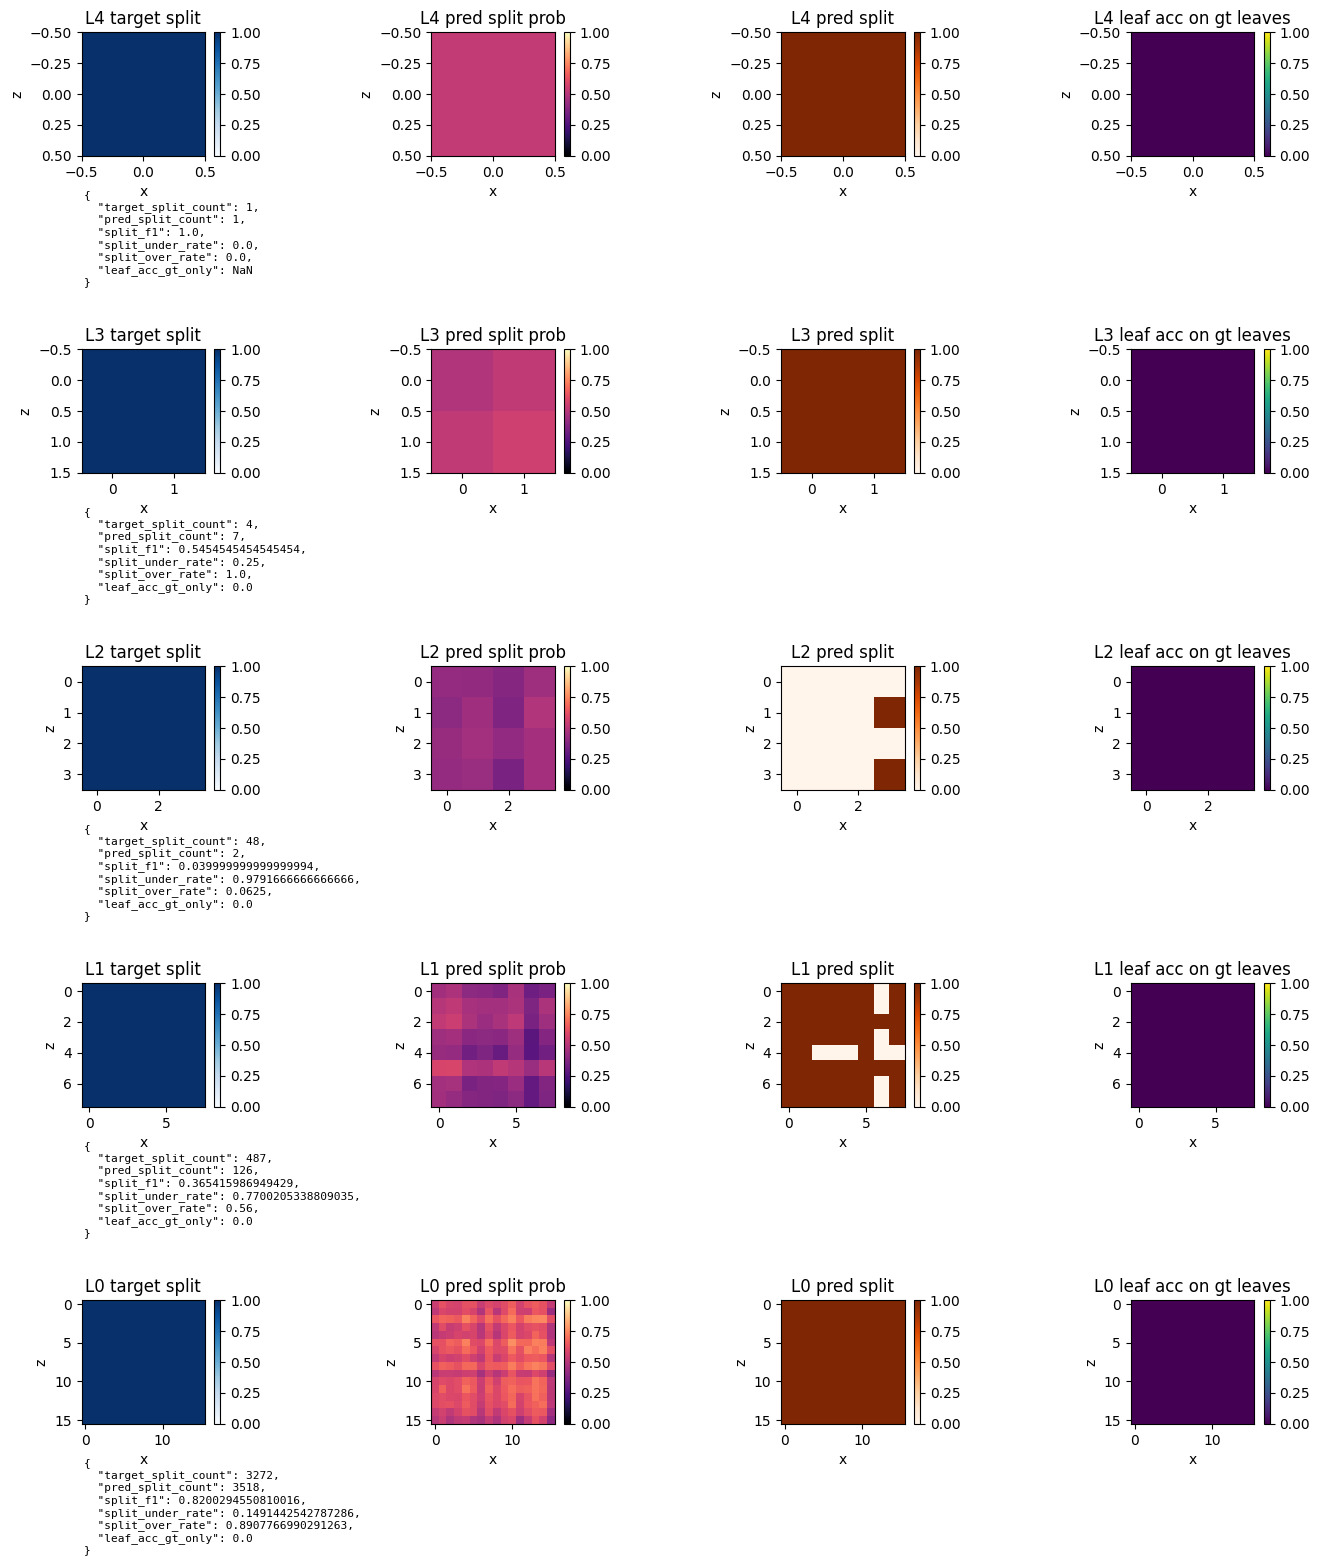

Plotted worst sample: 21


In [14]:
worst_idx = int(failure_table.iloc[0]['sample_idx'])
worst_report = plot_prediction_browser(
    CHECKPOINT_CANDIDATES[0],
    sample_idx=worst_idx,
    split_threshold=0.5,
)
print(f'Plotted worst sample: {worst_idx}')

## Threshold sweep and level confusion

Use these helpers to answer two concrete questions:
- does a different global split threshold help?
- which octree levels are under-splitting or over-splitting the most?

In [15]:
def _threshold_to_logit(split_threshold: float) -> float:
    if split_threshold <= 0.0:
        return float('-inf')
    if split_threshold >= 1.0:
        return float('inf')
    return math.log(split_threshold / (1.0 - split_threshold))


def _sample_prediction_cache(
    checkpoint_path: Path,
    *,
    data_path: Path = DATA_PATH,
    sample_indices: list[int] | None = None,
) -> tuple[dict[str, Any], list[dict[str, Any]]]:
    model, dataset, cfg = load_sparse_checkpoint(checkpoint_path, data_path=data_path)
    if sample_indices is None:
        sample_indices = list(range(len(dataset)))

    cached: list[dict[str, Any]] = []
    with torch.no_grad():
        for sample_idx in sample_indices:
            sample = dataset[sample_idx]
            preds = model(
                sample['noise_2d'].unsqueeze(0).to(DEVICE),
                sample['noise_3d'].unsqueeze(0).to(DEVICE),
                sample['biome_ids'].unsqueeze(0).to(DEVICE),
                sample['heightmap_surface'].unsqueeze(0).to(DEVICE),
                sample['heightmap_ocean_floor'].unsqueeze(0).to(DEVICE),
                position_bits=sample['position_bits'].unsqueeze(0).to(DEVICE),
            )
            per_level: dict[int, dict[str, torch.Tensor]] = {}
            for level, out in preds.items():
                per_level[int(level)] = {
                    'split_logits': out['split'][0].detach().cpu(),
                    'label_logits': out['label'][0].detach().cpu(),
                    'target_split': sample['targets'][level]['split'].detach().cpu(),
                    'target_label': sample['targets'][level]['label'].detach().cpu(),
                    'is_leaf': sample['targets'][level]['is_leaf'].detach().cpu(),
                }
            cached.append(
                {
                    'sample_idx': sample_idx,
                    'solid_fraction': 1.0 - float((dataset.subchunks[sample_idx] == 0).mean()),
                    'levels': per_level,
                }
            )
    return cfg, cached


def summarize_level_confusion(
    checkpoint_path: Path,
    *,
    split_threshold: float = 0.5,
    data_path: Path = DATA_PATH,
    sample_indices: list[int] | None = None,
) -> pd.DataFrame:
    cfg, cached = _sample_prediction_cache(
        checkpoint_path,
        data_path=data_path,
        sample_indices=sample_indices,
    )
    threshold_logit = _threshold_to_logit(split_threshold)

    rows: list[dict[str, Any]] = []
    levels = sorted(cached[0]['levels'].keys(), reverse=True) if cached else []
    for level in levels:
        tp = tn = fp = fn = 0.0
        leaf_correct = 0.0
        leaf_total = 0.0
        pred_leaf_nodes = 0.0
        gt_leaf_nodes = 0.0
        for item in cached:
            lvl = item['levels'][level]
            split_pred = lvl['split_logits'] > threshold_logit
            split_tgt = lvl['target_split'] > 0.5
            tp += float((split_pred & split_tgt).sum().item())
            tn += float(((~split_pred) & (~split_tgt)).sum().item())
            fp += float((split_pred & (~split_tgt)).sum().item())
            fn += float(((~split_pred) & split_tgt).sum().item())

            gt_leaf_mask = lvl['is_leaf'].bool()
            label_pred = lvl['label_logits'].argmax(dim=-1)
            if gt_leaf_mask.any():
                leaf_total += float(gt_leaf_mask.sum().item())
                leaf_correct += float((label_pred[gt_leaf_mask] == lvl['target_label'][gt_leaf_mask]).sum().item())
            pred_leaf_nodes += float((~split_pred).sum().item())
            gt_leaf_nodes += float((~split_tgt).sum().item())

        precision = tp / max(tp + fp, 1.0)
        recall = tp / max(tp + fn, 1.0)
        f1 = 2.0 * precision * recall / max(precision + recall, 1e-12)
        rows.append(
            {
                'level': level,
                'target_split_count': int(tp + fn),
                'pred_split_count': int(tp + fp),
                'split_precision': precision,
                'split_recall': recall,
                'split_f1': f1,
                'split_under_rate': fn / max(fn + tp, 1.0),
                'split_over_rate': fp / max(fp + tn, 1.0),
                'leaf_acc': leaf_correct / max(leaf_total, 1.0),
                'leaf_node_ratio': pred_leaf_nodes / max(gt_leaf_nodes, 1.0),
                'variant': cfg['model_variant'],
                'hidden': cfg['hidden'],
                'position_bits': cfg['position_bits'],
                'threshold': split_threshold,
            }
        )

    frame = pd.DataFrame(rows)
    return frame.sort_values('level', ascending=False)


def sweep_split_thresholds(
    checkpoint_path: Path,
    *,
    thresholds: list[float] | np.ndarray | None = None,
    data_path: Path = DATA_PATH,
    sample_indices: list[int] | None = None,
) -> pd.DataFrame:
    if thresholds is None:
        thresholds = np.linspace(0.1, 0.9, 17)
    cfg, cached = _sample_prediction_cache(
        checkpoint_path,
        data_path=data_path,
        sample_indices=sample_indices,
    )

    rows: list[dict[str, Any]] = []
    for threshold in thresholds:
        threshold_logit = _threshold_to_logit(float(threshold))
        metric_accum = {
            'split_tp': 0.0,
            'split_tn': 0.0,
            'split_fp': 0.0,
            'split_fn': 0.0,
            'leaf_correct': 0.0,
            'leaf_total': 0.0,
            'pred_leaf_nodes': 0.0,
            'gt_leaf_nodes': 0.0,
        }
        for item in cached:
            converted_preds: dict[int, dict[str, torch.Tensor]] = {}
            converted_targets: dict[int, dict[str, torch.Tensor]] = {}
            for level, lvl in item['levels'].items():
                split_pred = (lvl['split_logits'] > threshold_logit).float().unsqueeze(0)
                converted_preds[level] = {
                    'split': split_pred,
                    'label': lvl['label_logits'].unsqueeze(0),
                }
                converted_targets[level] = {
                    'split': lvl['target_split'].unsqueeze(0),
                    'label': lvl['target_label'].unsqueeze(0),
                    'is_leaf': lvl['is_leaf'].unsqueeze(0),
                }
            _update_batch_metrics(converted_preds, converted_targets, metric_accum)
        metrics = _finalize_metrics(metric_accum)
        rows.append(
            {
                'threshold': float(threshold),
                'split_f1': metrics['split_f1'],
                'split_under_rate': metrics['split_under_rate'],
                'split_over_rate': metrics['split_over_rate'],
                'leaf_acc': metrics['leaf_acc'],
                'leaf_node_ratio': metrics['leaf_node_ratio'],
                'variant': cfg['model_variant'],
                'hidden': cfg['hidden'],
                'position_bits': cfg['position_bits'],
            }
        )

    frame = pd.DataFrame(rows)
    return frame.sort_values(['split_f1', 'leaf_acc', 'split_under_rate'], ascending=[False, False, True])


def score_threshold_row(
    row: pd.Series,
    *,
    objective: str = 'split_f1_penalized_under',
    under_penalty: float = 2.0,
    over_penalty: float = 0.0,
    leaf_acc_weight: float = 0.0,
    leaf_ratio_penalty: float = 0.0,
    target_under_rate: float = 0.05,
) -> float:
    split_f1 = float(row['split_f1'])
    split_under_rate = float(row['split_under_rate'])
    split_over_rate = float(row['split_over_rate'])
    leaf_acc = float(row['leaf_acc'])
    leaf_node_ratio = float(row['leaf_node_ratio'])

    if objective == 'split_f1':
        return split_f1
    if objective == 'leaf_acc':
        return leaf_acc
    if objective == 'balanced':
        return (
            split_f1
            + leaf_acc_weight * leaf_acc
            - under_penalty * max(split_under_rate - target_under_rate, 0.0)
            - over_penalty * split_over_rate
            - leaf_ratio_penalty * abs(leaf_node_ratio - 1.0)
        )
    if objective == 'split_f1_penalized_under':
        return split_f1 - under_penalty * max(split_under_rate - target_under_rate, 0.0)

    raise ValueError(
        f'Unknown objective={objective!r}. Expected one of: '
        "'split_f1', 'leaf_acc', 'split_f1_penalized_under', 'balanced'"
    )


def find_best_split_threshold(
    checkpoint_path: Path,
    *,
    objective: str = 'split_f1_penalized_under',
    under_penalty: float = 2.0,
    over_penalty: float = 0.0,
    leaf_acc_weight: float = 0.0,
    leaf_ratio_penalty: float = 0.0,
    target_under_rate: float = 0.05,
    thresholds: list[float] | np.ndarray | None = None,
    data_path: Path = DATA_PATH,
    sample_indices: list[int] | None = None,
) -> tuple[pd.Series, pd.DataFrame]:
    frame = sweep_split_thresholds(
        checkpoint_path,
        thresholds=thresholds,
        data_path=data_path,
        sample_indices=sample_indices,
    ).copy()
    frame['objective'] = objective
    frame['score'] = frame.apply(
        lambda row: score_threshold_row(
            row,
            objective=objective,
            under_penalty=under_penalty,
            over_penalty=over_penalty,
            leaf_acc_weight=leaf_acc_weight,
            leaf_ratio_penalty=leaf_ratio_penalty,
            target_under_rate=target_under_rate,
        ),
        axis=1,
    )
    frame = frame.sort_values(
        ['score', 'split_f1', 'leaf_acc', 'split_under_rate'],
        ascending=[False, False, False, True],
    ).reset_index(drop=True)
    best = frame.iloc[0].copy()
    return best, frame


def plot_threshold_sweep(threshold_frame: pd.DataFrame, *, best_threshold: float | None = None) -> None:
    if threshold_frame.empty:
        print('No sweep results to plot.')
        return
    ordered = threshold_frame.sort_values('threshold')
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    axes[0].plot(ordered['threshold'], ordered['split_f1'], marker='o', label='split_f1')
    axes[0].plot(ordered['threshold'], ordered['leaf_acc'], marker='o', label='leaf_acc')
    axes[0].axhline(0.90, color='tab:green', linestyle='--', alpha=0.6)
    if best_threshold is not None:
        axes[0].axvline(best_threshold, color='tab:purple', linestyle=':', alpha=0.8, label=f'best={best_threshold:.3f}')
    axes[0].set_title('Metric vs threshold')
    axes[0].set_xlabel('split_threshold')
    axes[0].set_ylabel('score')
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    axes[1].plot(ordered['threshold'], ordered['split_under_rate'], marker='o', label='split_under_rate')
    axes[1].plot(ordered['threshold'], ordered['split_over_rate'], marker='o', label='split_over_rate')
    axes[1].axhline(0.05, color='tab:red', linestyle='--', alpha=0.6)
    if best_threshold is not None:
        axes[1].axvline(best_threshold, color='tab:purple', linestyle=':', alpha=0.8, label=f'best={best_threshold:.3f}')
    axes[1].set_title('Error rates vs threshold')
    axes[1].set_xlabel('split_threshold')
    axes[1].set_ylabel('rate')
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


# Example:
# threshold_frame = sweep_split_thresholds(CHECKPOINT_CANDIDATES[0], sample_indices=list(range(24)))
# best_threshold, ranked_thresholds = find_best_split_threshold(
#     CHECKPOINT_CANDIDATES[0],
#     sample_indices=list(range(24)),
#     objective='split_f1_penalized_under',
#     under_penalty=2.0,
#     target_under_rate=0.05,
# )
# display(ranked_thresholds.sort_values('threshold'))
# display(pd.DataFrame([best_threshold]))
# plot_threshold_sweep(ranked_thresholds, best_threshold=float(best_threshold['threshold']))
# display(summarize_level_confusion(CHECKPOINT_CANDIDATES[0], split_threshold=float(best_threshold['threshold']), sample_indices=list(range(24))))

In [16]:
threshold_frame = sweep_split_thresholds(
    CHECKPOINT_CANDIDATES[0],
    sample_indices=list(range(24)),
)
threshold_frame.sort_values('threshold')

,threshold,split_f1,split_under_rate,split_over_rate,leaf_acc,leaf_node_ratio,variant,hidden,position_bits
0,0.10,0.954585,0.000000,1.000000,0.0,0.000000,fast,32,17
1,0.15,0.954585,0.000000,1.000000,0.0,0.000000,fast,32,17
2,0.20,0.954351,0.000468,1.000000,0.0,0.004918,fast,32,17
3,0.25,0.952479,0.004211,1.000000,0.0,0.044258,fast,32,17
4,0.30,0.946230,0.016611,1.000000,0.0,0.174572,fast,32,17
5,0.35,0.936972,0.035366,0.992214,0.0,0.379469,fast,32,17
6,0.40,0.917450,0.073531,0.979408,0.0,0.793361,fast,32,17
7,0.45,0.884178,0.136572,0.942014,0.0,1.493290,fast,32,17
8,0.50,0.832732,0.227757,0.866817,0.0,2.526790,fast,32,17
9,0.55,0.751197,0.355536,0.750026,0.0,3.986477,fast,32,17


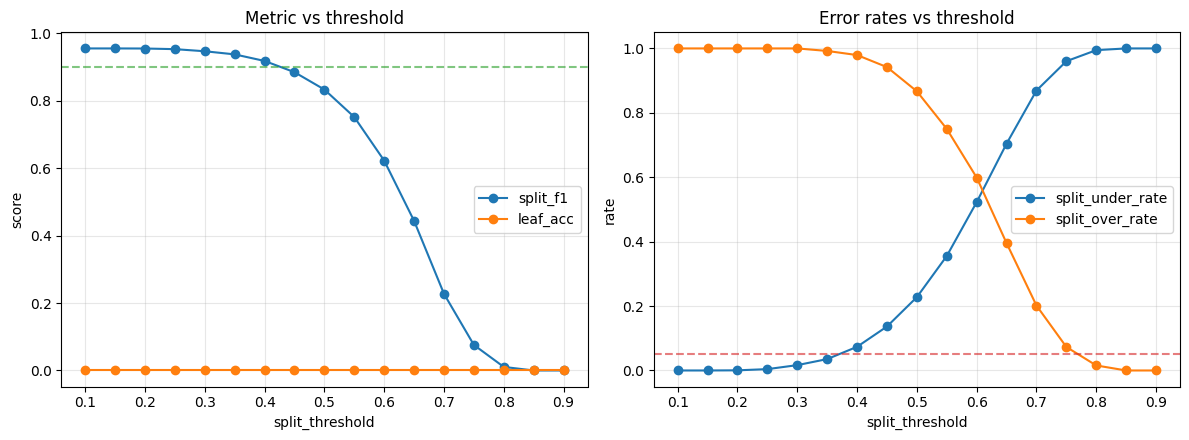

,level,target_split_count,pred_split_count,split_precision,split_recall,split_f1,split_under_rate,split_over_rate,leaf_acc,leaf_node_ratio,variant,hidden,position_bits,threshold
0,4,12,24,0.500000,1.000000,0.666667,0.000000,1.000000,0.0,0.000000,fast,32,17,0.5
1,3,144,168,0.714286,0.833333,0.769231,0.166667,1.000000,0.0,0.500000,fast,32,17,0.5
2,2,1344,48,0.750000,0.026786,0.051724,0.973214,0.062500,0.0,7.750000,fast,32,17,0.5
3,1,11891,3024,0.920304,0.234043,0.373181,0.765957,0.607053,0.0,23.335013,fast,32,17,0.5
4,0,89192,84416,0.903478,0.855099,0.878623,0.144901,0.894205,0.0,1.524144,fast,32,17,0.5


In [17]:
plot_threshold_sweep(threshold_frame)

level_confusion = summarize_level_confusion(
    CHECKPOINT_CANDIDATES[0],
    split_threshold=0.5,
    sample_indices=list(range(24)),
)
level_confusion

## Automatic best-threshold finder

Use this cell to score candidate split thresholds by a chosen objective. The default objective is `split_f1_penalized_under`, which maximizes `split_f1` while penalizing thresholds whose `split_under_rate` exceeds a target.

,threshold,split_f1,split_under_rate,split_over_rate,leaf_acc,leaf_node_ratio,variant,hidden,position_bits,objective,score
0,0.100,0.9546,0.0000,1.0000,0.0000,0.0000,fast,32,17,split_f1_penalized_under,0.9546
1,0.125,0.9546,0.0000,1.0000,0.0000,0.0000,fast,32,17,split_f1_penalized_under,0.9546
2,0.150,0.9546,0.0000,1.0000,0.0000,0.0000,fast,32,17,split_f1_penalized_under,0.9546
3,0.175,0.9546,0.0000,1.0000,0.0000,0.0000,fast,32,17,split_f1_penalized_under,0.9546
4,0.200,0.9544,0.0005,1.0000,0.0000,0.0049,fast,32,17,split_f1_penalized_under,0.9544
5,0.225,0.9536,0.0019,1.0000,0.0000,0.0197,fast,32,17,split_f1_penalized_under,0.9536
6,0.250,0.9525,0.0042,1.0000,0.0000,0.0443,fast,32,17,split_f1_penalized_under,0.9525
7,0.275,0.9503,0.0085,1.0000,0.0000,0.0893,fast,32,17,split_f1_penalized_under,0.9503
8,0.300,0.9462,0.0166,1.0000,0.0000,0.1746,fast,32,17,split_f1_penalized_under,0.9462
9,0.325,0.9423,0.0243,0.9991,0.0000,0.2565,fast,32,17,split_f1_penalized_under,0.9423


Best threshold = 0.100 for objective='split_f1_penalized_under' with score=0.9546


,threshold,split_f1,split_under_rate,split_over_rate,leaf_acc,leaf_node_ratio,variant,hidden,position_bits,objective,score
0,0.1,0.954585,0.0,1.0,0.0,0.0,fast,32,17,split_f1_penalized_under,0.954585


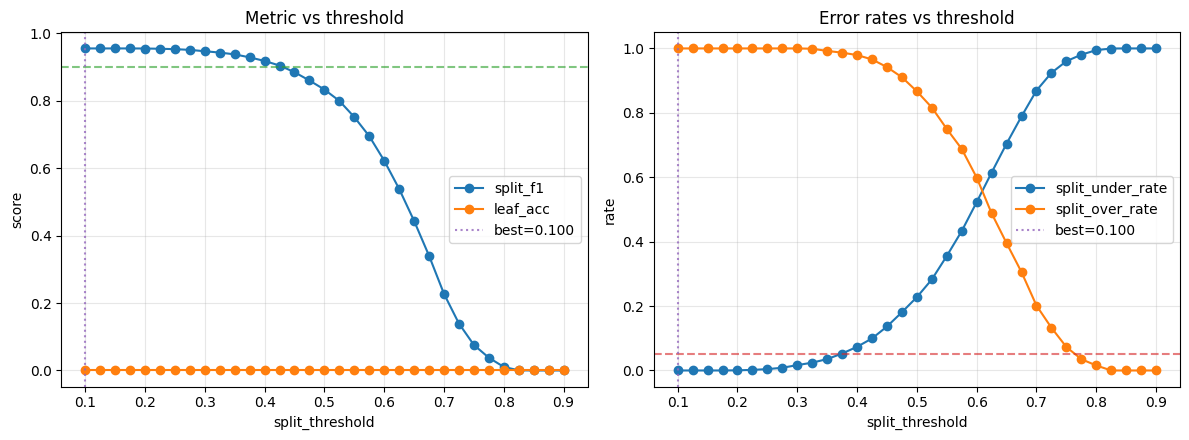

,level,target_split_count,pred_split_count,split_precision,split_recall,split_f1,split_under_rate,split_over_rate,leaf_acc,leaf_node_ratio,variant,hidden,position_bits,threshold
0,4,12,24,0.500000,1.0,0.666667,0.0,1.0,0.0,0.0,fast,32,17,0.1
1,3,144,192,0.750000,1.0,0.857143,0.0,1.0,0.0,0.0,fast,32,17,0.1
2,2,1344,1536,0.875000,1.0,0.933333,0.0,1.0,0.0,0.0,fast,32,17,0.1
3,1,11891,12288,0.967692,1.0,0.983581,0.0,1.0,0.0,0.0,fast,32,17,0.1
4,0,89192,98304,0.907308,1.0,0.951402,0.0,1.0,0.0,0.0,fast,32,17,0.1


In [18]:
BEST_THRESHOLD_OBJECTIVE = 'split_f1_penalized_under'
BEST_THRESHOLD_UNDER_PENALTY = 2.0
BEST_THRESHOLD_OVER_PENALTY = 0.0
BEST_THRESHOLD_LEAF_ACC_WEIGHT = 0.0
BEST_THRESHOLD_LEAF_RATIO_PENALTY = 0.0
BEST_THRESHOLD_TARGET_UNDER_RATE = 0.05
BEST_THRESHOLD_GRID = np.linspace(0.10, 0.90, 33)

best_threshold_row, ranked_thresholds = find_best_split_threshold(
    CHECKPOINT_CANDIDATES[0],
    sample_indices=list(range(24)),
    objective=BEST_THRESHOLD_OBJECTIVE,
    under_penalty=BEST_THRESHOLD_UNDER_PENALTY,
    over_penalty=BEST_THRESHOLD_OVER_PENALTY,
    leaf_acc_weight=BEST_THRESHOLD_LEAF_ACC_WEIGHT,
    leaf_ratio_penalty=BEST_THRESHOLD_LEAF_RATIO_PENALTY,
    target_under_rate=BEST_THRESHOLD_TARGET_UNDER_RATE,
    thresholds=BEST_THRESHOLD_GRID,
)

display(
    ranked_thresholds.sort_values('threshold').style.format(
        {
            'threshold': '{:.3f}',
            'split_f1': '{:.4f}',
            'split_under_rate': '{:.4f}',
            'split_over_rate': '{:.4f}',
            'leaf_acc': '{:.4f}',
            'leaf_node_ratio': '{:.4f}',
            'score': '{:.4f}',
        }
    )
)

print(
    f"Best threshold = {float(best_threshold_row['threshold']):.3f} "
    f"for objective={BEST_THRESHOLD_OBJECTIVE!r} with score={float(best_threshold_row['score']):.4f}"
)
display(pd.DataFrame([best_threshold_row]))

plot_threshold_sweep(
    ranked_thresholds,
    best_threshold=float(best_threshold_row['threshold']),
)

best_threshold_level_confusion = summarize_level_confusion(
    CHECKPOINT_CANDIDATES[0],
    split_threshold=float(best_threshold_row['threshold']),
    sample_indices=list(range(24)),
)
best_threshold_level_confusion

## Notes

Suggested first-pass gates from the sparse-octree README:
- `split_f1 >= 0.90`
- `split_under_rate <= 0.05`
- `leaf_node_ratio` in `[0.95, 1.10]`
- `leaf_acc >= 0.75`

This notebook uses a notebook-local holdout split because the current sparse trainer optimizes training loss only.

In [19]:
position_ablation_results = [
    run_quick_experiment(
        ExperimentConfig(
            name='fast_h64_no_posbits',
            hidden=64,
            model_variant='fast',
            max_samples=256,
            epochs=2,
            use_position_bits=False,
        )
    ),
    run_quick_experiment(
        ExperimentConfig(
            name='fast_h64_with_posbits',
            hidden=64,
            model_variant='fast',
            max_samples=256,
            epochs=2,
            use_position_bits=True,
        )
    ),
]

position_ablation_frame = pd.DataFrame(summarize_results(position_ablation_results))
display(position_ablation_frame)

if len(position_ablation_frame) == 2:
    baseline_row = position_ablation_frame[position_ablation_frame['use_position_bits'] == False].iloc[0]
    posbits_row = position_ablation_frame[position_ablation_frame['use_position_bits'] == True].iloc[0]
    delta = pd.DataFrame([
        {
            'metric': 'val_loss',
            'without_posbits': float(baseline_row['val_loss']),
            'with_posbits': float(posbits_row['val_loss']),
            'delta_with_minus_without': float(posbits_row['val_loss']) - float(baseline_row['val_loss']),
        },
        {
            'metric': 'split_f1',
            'without_posbits': float(baseline_row['split_f1']),
            'with_posbits': float(posbits_row['split_f1']),
            'delta_with_minus_without': float(posbits_row['split_f1']) - float(baseline_row['split_f1']),
        },
        {
            'metric': 'split_under_rate',
            'without_posbits': float(baseline_row['split_under_rate']),
            'with_posbits': float(posbits_row['split_under_rate']),
            'delta_with_minus_without': float(posbits_row['split_under_rate']) - float(baseline_row['split_under_rate']),
        },
        {
            'metric': 'leaf_acc',
            'without_posbits': float(baseline_row['leaf_acc']),
            'with_posbits': float(posbits_row['leaf_acc']),
            'delta_with_minus_without': float(posbits_row['leaf_acc']) - float(baseline_row['leaf_acc']),
        },
        {
            'metric': 'leaf_node_ratio',
            'without_posbits': float(baseline_row['leaf_node_ratio']),
            'with_posbits': float(posbits_row['leaf_node_ratio']),
            'delta_with_minus_without': float(posbits_row['leaf_node_ratio']) - float(baseline_row['leaf_node_ratio']),
        },
    ])
    display(delta)

save_results(position_ablation_results)

,name,variant,hidden,use_position_bits,epochs,best_epoch,val_loss,split_f1,split_under_rate,leaf_acc,leaf_node_ratio
0,fast_h64_no_posbits,fast,64,False,2,2,22.387985,0.632814,0.505806,0.004342,4.311015
1,fast_h64_with_posbits,fast,64,True,2,2,21.986761,0.526221,0.628326,0.002971,5.439214


,metric,without_posbits,with_posbits,delta_with_minus_without
0,val_loss,22.387985,21.986761,-0.401224
1,split_f1,0.632814,0.526221,-0.106593
2,split_under_rate,0.505806,0.628326,0.122521
3,leaf_acc,0.004342,0.002971,-0.001371
4,leaf_node_ratio,4.311015,5.439214,1.128199


(WindowsPath('C:/Users/JeffHall/git/MC/VoxelTree/runs/notebook_sparse_octree_ablation/sparse_octree_experiments_20260319_145704.json'),
 WindowsPath('C:/Users/JeffHall/git/MC/VoxelTree/runs/notebook_sparse_octree_ablation/sparse_octree_experiments_20260319_145704.csv'))

In [20]:
long_position_ablation_results = [
    run_quick_experiment(
        ExperimentConfig(
            name='fast_h64_no_posbits_e100',
            hidden=64,
            model_variant='fast',
            max_samples=256,
            epochs=100,
            use_position_bits=False,
        )
    ),
    run_quick_experiment(
        ExperimentConfig(
            name='fast_h64_with_posbits_e100',
            hidden=64,
            model_variant='fast',
            max_samples=256,
            epochs=100,
            use_position_bits=True,
        )
    ),
]

long_position_ablation_frame = pd.DataFrame(summarize_results(long_position_ablation_results))
display(long_position_ablation_frame)

if len(long_position_ablation_frame) == 2:
    long_baseline_row = long_position_ablation_frame[long_position_ablation_frame['use_position_bits'] == False].iloc[0]
    long_posbits_row = long_position_ablation_frame[long_position_ablation_frame['use_position_bits'] == True].iloc[0]
    long_delta = pd.DataFrame([
        {
            'metric': 'val_loss',
            'without_posbits': float(long_baseline_row['val_loss']),
            'with_posbits': float(long_posbits_row['val_loss']),
            'delta_with_minus_without': float(long_posbits_row['val_loss']) - float(long_baseline_row['val_loss']),
        },
        {
            'metric': 'split_f1',
            'without_posbits': float(long_baseline_row['split_f1']),
            'with_posbits': float(long_posbits_row['split_f1']),
            'delta_with_minus_without': float(long_posbits_row['split_f1']) - float(long_baseline_row['split_f1']),
        },
        {
            'metric': 'split_under_rate',
            'without_posbits': float(long_baseline_row['split_under_rate']),
            'with_posbits': float(long_posbits_row['split_under_rate']),
            'delta_with_minus_without': float(long_posbits_row['split_under_rate']) - float(long_baseline_row['split_under_rate']),
        },
        {
            'metric': 'leaf_acc',
            'without_posbits': float(long_baseline_row['leaf_acc']),
            'with_posbits': float(long_posbits_row['leaf_acc']),
            'delta_with_minus_without': float(long_posbits_row['leaf_acc']) - float(long_baseline_row['leaf_acc']),
        },
        {
            'metric': 'leaf_node_ratio',
            'without_posbits': float(long_baseline_row['leaf_node_ratio']),
            'with_posbits': float(long_posbits_row['leaf_node_ratio']),
            'delta_with_minus_without': float(long_posbits_row['leaf_node_ratio']) - float(long_baseline_row['leaf_node_ratio']),
        },
    ])
    display(long_delta)

save_results(long_position_ablation_results)

,name,variant,hidden,use_position_bits,epochs,best_epoch,val_loss,split_f1,split_under_rate,leaf_acc,leaf_node_ratio
0,fast_h64_no_posbits_e100,fast,64,False,100,97,4.872566,0.931271,0.022224,0.596892,0.245201
1,fast_h64_with_posbits_e100,fast,64,True,100,100,5.152508,0.347344,0.781235,0.510969,6.595293


,metric,without_posbits,with_posbits,delta_with_minus_without
0,val_loss,4.872566,5.152508,0.279942
1,split_f1,0.931271,0.347344,-0.583927
2,split_under_rate,0.022224,0.781235,0.759011
3,leaf_acc,0.596892,0.510969,-0.085923
4,leaf_node_ratio,0.245201,6.595293,6.350091


(WindowsPath('C:/Users/JeffHall/git/MC/VoxelTree/runs/notebook_sparse_octree_ablation/sparse_octree_experiments_20260319_150350.json'),
 WindowsPath('C:/Users/JeffHall/git/MC/VoxelTree/runs/notebook_sparse_octree_ablation/sparse_octree_experiments_20260319_150350.csv'))

In [21]:
from torch.utils.data import Dataset


def encode_position_scalars(chunk_x: int, chunk_z: int, section_y: int) -> np.ndarray:
    x_mod = (int(chunk_x) % 16) / 15.0
    z_mod = (int(chunk_z) % 16) / 15.0
    block_y = int(section_y) * 16
    y_norm = (block_y + 64.0) / 384.0  # overworld range [-64, 320] -> [0, 1]
    y_norm = float(np.clip(y_norm, 0.0, 1.0))
    return np.array([x_mod, z_mod, y_norm], dtype=np.float32)


class PositionFeatureDataset(Dataset):
    def __init__(self, base_dataset: SparseOctreeDataset, scheme: str) -> None:
        self.base_dataset = base_dataset
        self.scheme = scheme
        self.spatial_y = base_dataset.spatial_y
        self.has_positions = bool(getattr(base_dataset, 'has_positions', False))

    def __len__(self) -> int:
        return len(self.base_dataset)

    def __getitem__(self, idx: int) -> dict[str, Any]:
        sample = dict(self.base_dataset[idx])
        if self.scheme == 'none':
            sample['position_bits'] = torch.zeros(0, dtype=torch.float32)
        elif self.scheme == 'bits17':
            pass
        elif self.scheme == 'scalar3':
            if self.has_positions:
                features = encode_position_scalars(
                    int(self.base_dataset.chunk_x[idx]),
                    int(self.base_dataset.chunk_z[idx]),
                    int(self.base_dataset.section_y[idx]),
                )
            else:
                features = np.zeros(3, dtype=np.float32)
            sample['position_bits'] = torch.from_numpy(features)
        else:
            raise ValueError(f'Unknown position scheme: {self.scheme!r}')
        return sample


def run_position_scheme_experiment(
    config: ExperimentConfig,
    *,
    position_scheme: str,
    data_path: Path = DATA_PATH,
    output_dir: Path = OUTPUT_DIR,
    device: str = DEVICE,
) -> dict[str, Any]:
    set_seed(config.seed)
    base_dataset = SparseOctreeDataset(data_path, cache_targets=config.cache_targets)
    dataset = PositionFeatureDataset(base_dataset, position_scheme)
    train_idx, val_idx = split_indices(
        len(dataset),
        holdout_fraction=config.holdout_fraction,
        seed=config.seed,
        max_samples=config.max_samples,
    )
    train_loader = make_loader(dataset, train_idx, config.batch_size, shuffle=True)
    val_loader = make_loader(dataset, val_idx, config.batch_size, shuffle=False)

    sample = dataset[train_idx[0]]
    model = _build_model(
        config.model_variant,
        n2d=int(sample['noise_2d'].shape[0]),
        n3d=int(sample['noise_3d'].shape[0]),
        hidden=config.hidden,
        num_classes=config.num_classes,
        spatial_y=int(dataset.spatial_y),
        position_bits=int(sample['position_bits'].shape[0]),
    ).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=config.lr)
    max_level = getattr(model, 'max_level', 4)
    level_split_weights, level_label_weights = _default_level_weights(int(max_level))

    best_val_loss = float('inf')
    best_epoch = -1
    best_state = None
    best_val_metrics = None
    history: list[dict[str, float]] = []

    for epoch in range(1, config.epochs + 1):
        model.train()
        total_loss = 0.0
        total_batches = 0
        metric_accum = {
            'split_tp': 0.0,
            'split_tn': 0.0,
            'split_fp': 0.0,
            'split_fn': 0.0,
            'leaf_correct': 0.0,
            'leaf_total': 0.0,
            'pred_leaf_nodes': 0.0,
            'gt_leaf_nodes': 0.0,
        }
        for batch in train_loader:
            noise_2d = batch['noise_2d'].to(device)
            noise_3d = batch['noise_3d'].to(device)
            biome_ids = batch['biome_ids'].to(device)
            heightmap_surface = batch['heightmap_surface'].to(device)
            heightmap_ocean_floor = batch['heightmap_ocean_floor'].to(device)
            position_bits = batch['position_bits'].to(device)
            optimizer.zero_grad()
            preds = model(
                noise_2d,
                noise_3d,
                biome_ids,
                heightmap_surface,
                heightmap_ocean_floor,
                position_bits=position_bits,
            )
            loss = _sparse_octree_loss(
                preds,
                batch['targets'],
                split_weight=config.split_weight,
                label_weight=config.label_weight,
                level_split_weights=level_split_weights,
                level_label_weights=level_label_weights,
                label_smoothing=config.label_smoothing,
                dynamic_split_pos_weight=True,
            )
            loss.backward()
            optimizer.step()
            total_loss += float(loss.detach().cpu())
            total_batches += 1
            _update_batch_metrics(preds, batch['targets'], metric_accum)

        train_metrics = {'loss': total_loss / max(total_batches, 1)}
        train_metrics.update(_finalize_metrics(metric_accum))
        val_metrics = evaluate_model(
            model,
            val_loader,
            device,
            split_weight=config.split_weight,
            label_weight=config.label_weight,
            label_smoothing=config.label_smoothing,
        )

        row = {'epoch': float(epoch)}
        row.update({f'train_{k}': float(v) for k, v in train_metrics.items()})
        row.update({f'val_{k}': float(v) for k, v in val_metrics.items()})
        history.append(row)

        if val_metrics['loss'] < best_val_loss:
            best_val_loss = float(val_metrics['loss'])
            best_epoch = epoch
            best_val_metrics = dict(val_metrics)
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    checkpoint_path = output_dir / f'{config.name}_{position_scheme}.pt'
    checkpoint_path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(best_state if best_state is not None else model.state_dict(), checkpoint_path)

    result = {
        'name': config.name,
        'config': {**asdict(config), 'position_scheme': position_scheme},
        'checkpoint': str(checkpoint_path),
        'train_samples': len(train_idx),
        'val_samples': len(val_idx),
        'best_epoch': best_epoch,
        'best_val_loss': best_val_loss,
        'best_val_metrics': best_val_metrics,
        'history': history,
    }
    return result


scalar_position_results = [
    run_position_scheme_experiment(
        ExperimentConfig(
            name='fast_h64_none_e100',
            hidden=64,
            model_variant='fast',
            max_samples=256,
            epochs=100,
            use_position_bits=False,
        ),
        position_scheme='none',
    ),
    run_position_scheme_experiment(
        ExperimentConfig(
            name='fast_h64_bits17_e100',
            hidden=64,
            model_variant='fast',
            max_samples=256,
            epochs=100,
            use_position_bits=True,
        ),
        position_scheme='bits17',
    ),
    run_position_scheme_experiment(
        ExperimentConfig(
            name='fast_h64_scalar3_e100',
            hidden=64,
            model_variant='fast',
            max_samples=256,
            epochs=100,
            use_position_bits=True,
        ),
        position_scheme='scalar3',
    ),
]

scalar_position_frame = pd.DataFrame(summarize_results(scalar_position_results))
if 'position_scheme' in scalar_position_results[0]['config']:
    scalar_position_frame['position_scheme'] = [r['config']['position_scheme'] for r in scalar_position_results]
scalar_position_frame = scalar_position_frame[
    ['name', 'position_scheme', 'variant', 'hidden', 'epochs', 'best_epoch', 'val_loss', 'split_f1', 'split_under_rate', 'leaf_acc', 'leaf_node_ratio']
]
display(scalar_position_frame.sort_values('split_f1', ascending=False))

save_results(scalar_position_results)

,name,position_scheme,variant,hidden,epochs,best_epoch,val_loss,split_f1,split_under_rate,leaf_acc,leaf_node_ratio
0,fast_h64_none_e100,none,fast,64,100,97,4.872566,0.931271,0.022224,0.596892,0.245201
1,fast_h64_scalar3_e100,bits17,fast,64,100,98,4.923830,0.910007,0.080279,0.551874,0.838665
2,fast_h64_bits17_e100,scalar3,fast,64,100,100,5.152508,0.347344,0.781235,0.510969,6.595293


(WindowsPath('C:/Users/JeffHall/git/MC/VoxelTree/runs/notebook_sparse_octree_ablation/sparse_octree_experiments_20260319_151904.json'),
 WindowsPath('C:/Users/JeffHall/git/MC/VoxelTree/runs/notebook_sparse_octree_ablation/sparse_octree_experiments_20260319_151904.csv'))

In [22]:
scalar_position_frame_corrected = pd.DataFrame([
    {
        'name': r['name'],
        'position_scheme': r['config']['position_scheme'],
        'variant': r['config']['model_variant'],
        'hidden': r['config']['hidden'],
        'epochs': r['config']['epochs'],
        'best_epoch': r['best_epoch'],
        'val_loss': r['best_val_metrics']['loss'],
        'split_f1': r['best_val_metrics']['split_f1'],
        'split_under_rate': r['best_val_metrics']['split_under_rate'],
        'leaf_acc': r['best_val_metrics']['leaf_acc'],
        'leaf_node_ratio': r['best_val_metrics']['leaf_node_ratio'],
    }
    for r in scalar_position_results
]).sort_values('split_f1', ascending=False)

display(scalar_position_frame_corrected)

,name,position_scheme,variant,hidden,epochs,best_epoch,val_loss,split_f1,split_under_rate,leaf_acc,leaf_node_ratio
0,fast_h64_none_e100,none,fast,64,100,97,4.872566,0.931271,0.022224,0.596892,0.245201
2,fast_h64_scalar3_e100,scalar3,fast,64,100,98,4.923830,0.910007,0.080279,0.551874,0.838665
1,fast_h64_bits17_e100,bits17,fast,64,100,100,5.152508,0.347344,0.781235,0.510969,6.595293


In [23]:
def encode_position_subset(chunk_x: int, chunk_z: int, section_y: int, scheme: str) -> np.ndarray:
    x_mod = (int(chunk_x) % 16) / 15.0
    z_mod = (int(chunk_z) % 16) / 15.0
    block_y = int(section_y) * 16
    y_norm = float(np.clip((block_y + 64.0) / 384.0, 0.0, 1.0))

    if scheme == 'xz_scalar2':
        return np.array([x_mod, z_mod], dtype=np.float32)
    if scheme == 'y_scalar1':
        return np.array([y_norm], dtype=np.float32)
    if scheme == 'scalar3':
        return np.array([x_mod, z_mod, y_norm], dtype=np.float32)
    if scheme == 'none':
        return np.zeros(0, dtype=np.float32)
    raise ValueError(f'Unknown subset position scheme: {scheme!r}')


class PositionSubsetDataset(Dataset):
    def __init__(self, base_dataset: SparseOctreeDataset, scheme: str) -> None:
        self.base_dataset = base_dataset
        self.scheme = scheme
        self.spatial_y = base_dataset.spatial_y
        self.has_positions = bool(getattr(base_dataset, 'has_positions', False))

    def __len__(self) -> int:
        return len(self.base_dataset)

    def __getitem__(self, idx: int) -> dict[str, Any]:
        sample = dict(self.base_dataset[idx])
        if self.has_positions:
            feats = encode_position_subset(
                int(self.base_dataset.chunk_x[idx]),
                int(self.base_dataset.chunk_z[idx]),
                int(self.base_dataset.section_y[idx]),
                self.scheme,
            )
        else:
            feats = encode_position_subset(0, 0, 0, self.scheme)
        sample['position_bits'] = torch.from_numpy(feats)
        return sample


def run_position_subset_experiment(
    config: ExperimentConfig,
    *,
    position_scheme: str,
    data_path: Path = DATA_PATH,
    output_dir: Path = OUTPUT_DIR,
    device: str = DEVICE,
) -> dict[str, Any]:
    set_seed(config.seed)
    base_dataset = SparseOctreeDataset(data_path, cache_targets=config.cache_targets)
    dataset = PositionSubsetDataset(base_dataset, position_scheme)
    train_idx, val_idx = split_indices(
        len(dataset),
        holdout_fraction=config.holdout_fraction,
        seed=config.seed,
        max_samples=config.max_samples,
    )
    train_loader = make_loader(dataset, train_idx, config.batch_size, shuffle=True)
    val_loader = make_loader(dataset, val_idx, config.batch_size, shuffle=False)

    sample = dataset[train_idx[0]]
    model = _build_model(
        config.model_variant,
        n2d=int(sample['noise_2d'].shape[0]),
        n3d=int(sample['noise_3d'].shape[0]),
        hidden=config.hidden,
        num_classes=config.num_classes,
        spatial_y=int(dataset.spatial_y),
        position_bits=int(sample['position_bits'].shape[0]),
    ).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=config.lr)
    max_level = getattr(model, 'max_level', 4)
    level_split_weights, level_label_weights = _default_level_weights(int(max_level))

    best_val_loss = float('inf')
    best_epoch = -1
    best_state = None
    best_val_metrics = None
    history: list[dict[str, float]] = []

    for epoch in range(1, config.epochs + 1):
        model.train()
        total_loss = 0.0
        total_batches = 0
        metric_accum = {
            'split_tp': 0.0,
            'split_tn': 0.0,
            'split_fp': 0.0,
            'split_fn': 0.0,
            'leaf_correct': 0.0,
            'leaf_total': 0.0,
            'pred_leaf_nodes': 0.0,
            'gt_leaf_nodes': 0.0,
        }
        for batch in train_loader:
            noise_2d = batch['noise_2d'].to(device)
            noise_3d = batch['noise_3d'].to(device)
            biome_ids = batch['biome_ids'].to(device)
            heightmap_surface = batch['heightmap_surface'].to(device)
            heightmap_ocean_floor = batch['heightmap_ocean_floor'].to(device)
            position_bits = batch['position_bits'].to(device)
            optimizer.zero_grad()
            preds = model(
                noise_2d,
                noise_3d,
                biome_ids,
                heightmap_surface,
                heightmap_ocean_floor,
                position_bits=position_bits,
            )
            loss = _sparse_octree_loss(
                preds,
                batch['targets'],
                split_weight=config.split_weight,
                label_weight=config.label_weight,
                level_split_weights=level_split_weights,
                level_label_weights=level_label_weights,
                label_smoothing=config.label_smoothing,
                dynamic_split_pos_weight=True,
            )
            loss.backward()
            optimizer.step()
            total_loss += float(loss.detach().cpu())
            total_batches += 1
            _update_batch_metrics(preds, batch['targets'], metric_accum)

        train_metrics = {'loss': total_loss / max(total_batches, 1)}
        train_metrics.update(_finalize_metrics(metric_accum))
        val_metrics = evaluate_model(
            model,
            val_loader,
            device,
            split_weight=config.split_weight,
            label_weight=config.label_weight,
            label_smoothing=config.label_smoothing,
        )

        row = {'epoch': float(epoch)}
        row.update({f'train_{k}': float(v) for k, v in train_metrics.items()})
        row.update({f'val_{k}': float(v) for k, v in val_metrics.items()})
        history.append(row)

        if val_metrics['loss'] < best_val_loss:
            best_val_loss = float(val_metrics['loss'])
            best_epoch = epoch
            best_val_metrics = dict(val_metrics)
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    checkpoint_path = output_dir / f'{config.name}_{position_scheme}.pt'
    torch.save(best_state if best_state is not None else model.state_dict(), checkpoint_path)
    return {
        'name': config.name,
        'config': {**asdict(config), 'position_scheme': position_scheme},
        'checkpoint': str(checkpoint_path),
        'train_samples': len(train_idx),
        'val_samples': len(val_idx),
        'best_epoch': best_epoch,
        'best_val_loss': best_val_loss,
        'best_val_metrics': best_val_metrics,
        'history': history,
    }


subset_position_results = []
if 'scalar_position_results' in globals():
    for result in scalar_position_results:
        if result['config']['position_scheme'] in {'none', 'scalar3'}:
            subset_position_results.append(result)

subset_position_results.extend([
    run_position_subset_experiment(
        ExperimentConfig(
            name='fast_h64_xz_scalar2_e100',
            hidden=64,
            model_variant='fast',
            max_samples=256,
            epochs=100,
            use_position_bits=True,
        ),
        position_scheme='xz_scalar2',
    ),
    run_position_subset_experiment(
        ExperimentConfig(
            name='fast_h64_y_scalar1_e100',
            hidden=64,
            model_variant='fast',
            max_samples=256,
            epochs=100,
            use_position_bits=True,
        ),
        position_scheme='y_scalar1',
    ),
])

subset_position_frame = pd.DataFrame([
    {
        'name': r['name'],
        'position_scheme': r['config']['position_scheme'],
        'variant': r['config']['model_variant'],
        'hidden': r['config']['hidden'],
        'epochs': r['config']['epochs'],
        'best_epoch': r['best_epoch'],
        'val_loss': r['best_val_metrics']['loss'],
        'split_f1': r['best_val_metrics']['split_f1'],
        'split_under_rate': r['best_val_metrics']['split_under_rate'],
        'leaf_acc': r['best_val_metrics']['leaf_acc'],
        'leaf_node_ratio': r['best_val_metrics']['leaf_node_ratio'],
    }
    for r in subset_position_results
]).sort_values('split_f1', ascending=False)

display(subset_position_frame)
save_results(subset_position_results)

,name,position_scheme,variant,hidden,epochs,best_epoch,val_loss,split_f1,split_under_rate,leaf_acc,leaf_node_ratio
0,fast_h64_none_e100,none,fast,64,100,97,4.872566,0.931271,0.022224,0.596892,0.245201
1,fast_h64_scalar3_e100,scalar3,fast,64,100,98,4.923830,0.910007,0.080279,0.551874,0.838665
3,fast_h64_y_scalar1_e100,y_scalar1,fast,64,100,97,4.907712,0.323644,0.803550,0.539991,6.940356
2,fast_h64_xz_scalar2_e100,xz_scalar2,fast,64,100,99,4.820112,0.211666,0.880836,0.556444,7.605576


(WindowsPath('C:/Users/JeffHall/git/MC/VoxelTree/runs/notebook_sparse_octree_ablation/sparse_octree_experiments_20260319_152559.json'),
 WindowsPath('C:/Users/JeffHall/git/MC/VoxelTree/runs/notebook_sparse_octree_ablation/sparse_octree_experiments_20260319_152559.csv'))

In [24]:
class CoarseYConditionedFastModel(torch.nn.Module):
    def __init__(
        self,
        n2d: int,
        n3d: int,
        hidden: int,
        num_classes: int,
        levels: int = 5,
        spatial_y: int = 2,
        coarse_levels: tuple[int, ...] | None = None,
    ) -> None:
        super().__init__()
        self.hidden = hidden
        self.num_classes = num_classes
        self.levels = levels
        self.max_level = levels - 1
        self.coarse_levels = tuple(coarse_levels or (self.max_level, self.max_level - 1, self.max_level - 2))

        label_rank = max(48, min(hidden, (hidden * 2) // 3))
        child_rank = max(32, hidden // 2)
        split_rank = max(24, hidden // 3)

        self.noise_enc = sparse_octree_mod._NoiseEncoder(
            n2d,
            n3d,
            hidden,
            spatial_y=spatial_y,
            position_bits=0,
        )
        self.pos_emb = sparse_octree_mod._OctreePosEmb(hidden)
        self.root_proj = torch.nn.Sequential(
            torch.nn.Linear(hidden, hidden),
            torch.nn.SiLU(),
        )
        self.level_mod = torch.nn.ModuleList(sparse_octree_mod._LevelFiLM(hidden) for _ in range(levels))
        self.split_head = sparse_octree_mod._FactorizedHead(hidden, 1, split_rank)
        self.label_head = sparse_octree_mod._FactorizedHead(hidden, num_classes, label_rank)
        self.child_proj = sparse_octree_mod._FactorizedHead(hidden, hidden * 8, child_rank)

        self.y_root = torch.nn.Sequential(
            torch.nn.Linear(1, hidden),
            torch.nn.Tanh(),
        )
        self.y_level_mod = torch.nn.ModuleDict({
            str(level): torch.nn.Linear(1, hidden * 2)
            for level in self.coarse_levels
        })

    def forward(
        self,
        noise_2d: torch.Tensor,
        noise_3d: torch.Tensor,
        biome_ids: torch.Tensor,
        heightmap_surface: torch.Tensor,
        heightmap_ocean_floor: torch.Tensor,
        position_bits: torch.Tensor | None = None,
    ) -> dict[int, dict[str, torch.Tensor]]:
        B = noise_2d.shape[0]
        device = noise_2d.device
        ctx = self.noise_enc(
            noise_2d,
            noise_3d,
            biome_ids,
            heightmap_surface,
            heightmap_ocean_floor,
            position_bits=None,
        )
        if position_bits is not None and position_bits.shape[1] > 0:
            y_scalar = position_bits[:, :1].to(ctx.dtype)
        else:
            y_scalar = torch.zeros((B, 1), device=device, dtype=ctx.dtype)

        cur_feat = (self.root_proj(ctx) + 0.1 * self.y_root(y_scalar)).unsqueeze(1)
        outputs: dict[int, dict[str, torch.Tensor]] = {}

        for lvl in range(self.max_level, -1, -1):
            N = cur_feat.shape[1]
            pe = self.pos_emb(lvl, device)
            scale, shift = self.level_mod[self.max_level - lvl](ctx)
            feat = cur_feat + pe.unsqueeze(0)
            feat = feat * scale.unsqueeze(1) + shift.unsqueeze(1)

            if lvl in self.coarse_levels:
                y_scale, y_shift = self.y_level_mod[str(lvl)](y_scalar).chunk(2, dim=-1)
                y_scale = 1.0 + 0.1 * torch.tanh(y_scale)
                y_shift = 0.1 * torch.tanh(y_shift)
                feat = feat * y_scale.unsqueeze(1) + y_shift.unsqueeze(1)

            flat = feat.reshape(B * N, self.hidden)
            split_logits = self.split_head(flat).reshape(B, N)
            label_logits = self.label_head(flat).reshape(B, N, self.num_classes)
            outputs[lvl] = {'split': split_logits, 'label': label_logits}

            if lvl == 0:
                break
            cur_feat = self.child_proj(flat).reshape(B, N * 8, self.hidden)

        return outputs


def run_coarse_y_conditioning_experiment(
    config: ExperimentConfig,
    *,
    data_path: Path = DATA_PATH,
    output_dir: Path = OUTPUT_DIR,
    device: str = DEVICE,
) -> dict[str, Any]:
    set_seed(config.seed)
    base_dataset = SparseOctreeDataset(data_path, cache_targets=config.cache_targets)
    dataset = PositionSubsetDataset(base_dataset, 'y_scalar1')
    train_idx, val_idx = split_indices(
        len(dataset),
        holdout_fraction=config.holdout_fraction,
        seed=config.seed,
        max_samples=config.max_samples,
    )
    train_loader = make_loader(dataset, train_idx, config.batch_size, shuffle=True)
    val_loader = make_loader(dataset, val_idx, config.batch_size, shuffle=False)

    sample = dataset[train_idx[0]]
    model = CoarseYConditionedFastModel(
        n2d=int(sample['noise_2d'].shape[0]),
        n3d=int(sample['noise_3d'].shape[0]),
        hidden=config.hidden,
        num_classes=config.num_classes,
        spatial_y=int(dataset.spatial_y),
    ).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=config.lr)
    max_level = getattr(model, 'max_level', 4)
    level_split_weights, level_label_weights = _default_level_weights(int(max_level))

    best_val_loss = float('inf')
    best_epoch = -1
    best_state = None
    best_val_metrics = None
    history: list[dict[str, float]] = []

    for epoch in range(1, config.epochs + 1):
        model.train()
        total_loss = 0.0
        total_batches = 0
        metric_accum = {
            'split_tp': 0.0,
            'split_tn': 0.0,
            'split_fp': 0.0,
            'split_fn': 0.0,
            'leaf_correct': 0.0,
            'leaf_total': 0.0,
            'pred_leaf_nodes': 0.0,
            'gt_leaf_nodes': 0.0,
        }
        for batch in train_loader:
            noise_2d = batch['noise_2d'].to(device)
            noise_3d = batch['noise_3d'].to(device)
            biome_ids = batch['biome_ids'].to(device)
            heightmap_surface = batch['heightmap_surface'].to(device)
            heightmap_ocean_floor = batch['heightmap_ocean_floor'].to(device)
            position_bits = batch['position_bits'].to(device)
            optimizer.zero_grad()
            preds = model(
                noise_2d,
                noise_3d,
                biome_ids,
                heightmap_surface,
                heightmap_ocean_floor,
                position_bits=position_bits,
            )
            loss = _sparse_octree_loss(
                preds,
                batch['targets'],
                split_weight=config.split_weight,
                label_weight=config.label_weight,
                level_split_weights=level_split_weights,
                level_label_weights=level_label_weights,
                label_smoothing=config.label_smoothing,
                dynamic_split_pos_weight=True,
            )
            loss.backward()
            optimizer.step()
            total_loss += float(loss.detach().cpu())
            total_batches += 1
            _update_batch_metrics(preds, batch['targets'], metric_accum)

        train_metrics = {'loss': total_loss / max(total_batches, 1)}
        train_metrics.update(_finalize_metrics(metric_accum))
        val_metrics = evaluate_model(
            model,
            val_loader,
            device,
            split_weight=config.split_weight,
            label_weight=config.label_weight,
            label_smoothing=config.label_smoothing,
        )

        row = {'epoch': float(epoch)}
        row.update({f'train_{k}': float(v) for k, v in train_metrics.items()})
        row.update({f'val_{k}': float(v) for k, v in val_metrics.items()})
        history.append(row)

        if val_metrics['loss'] < best_val_loss:
            best_val_loss = float(val_metrics['loss'])
            best_epoch = epoch
            best_val_metrics = dict(val_metrics)
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    checkpoint_path = output_dir / f'{config.name}_coarse_y_conditioned.pt'
    torch.save(best_state if best_state is not None else model.state_dict(), checkpoint_path)
    return {
        'name': config.name,
        'config': {**asdict(config), 'position_scheme': 'coarse_y_conditioned'},
        'checkpoint': str(checkpoint_path),
        'train_samples': len(train_idx),
        'val_samples': len(val_idx),
        'best_epoch': best_epoch,
        'best_val_loss': best_val_loss,
        'best_val_metrics': best_val_metrics,
        'history': history,
    }


coarse_y_results = []
if 'subset_position_results' in globals():
    for result in subset_position_results:
        if result['config']['position_scheme'] in {'none', 'y_scalar1'}:
            coarse_y_results.append(result)

coarse_y_results.append(
    run_coarse_y_conditioning_experiment(
        ExperimentConfig(
            name='fast_h64_coarse_y_conditioned_e100',
            hidden=64,
            model_variant='fast',
            max_samples=256,
            epochs=100,
            use_position_bits=True,
        )
    )
)

coarse_y_frame = pd.DataFrame([
    {
        'name': r['name'],
        'position_scheme': r['config']['position_scheme'],
        'variant': r['config']['model_variant'],
        'hidden': r['config']['hidden'],
        'epochs': r['config']['epochs'],
        'best_epoch': r['best_epoch'],
        'val_loss': r['best_val_metrics']['loss'],
        'split_f1': r['best_val_metrics']['split_f1'],
        'split_under_rate': r['best_val_metrics']['split_under_rate'],
        'leaf_acc': r['best_val_metrics']['leaf_acc'],
        'leaf_node_ratio': r['best_val_metrics']['leaf_node_ratio'],
    }
    for r in coarse_y_results
]).sort_values('split_f1', ascending=False)

display(coarse_y_frame)
save_results(coarse_y_results)

,name,position_scheme,variant,hidden,epochs,best_epoch,val_loss,split_f1,split_under_rate,leaf_acc,leaf_node_ratio
0,fast_h64_none_e100,none,fast,64,100,97,4.872566,0.931271,0.022224,0.596892,0.245201
2,fast_h64_coarse_y_conditioned_e100,coarse_y_conditioned,fast,64,100,100,4.898711,0.929403,0.029511,0.551874,0.331810
1,fast_h64_y_scalar1_e100,y_scalar1,fast,64,100,97,4.907712,0.323644,0.803550,0.539991,6.940356


(WindowsPath('C:/Users/JeffHall/git/MC/VoxelTree/runs/notebook_sparse_octree_ablation/sparse_octree_experiments_20260319_153006.json'),
 WindowsPath('C:/Users/JeffHall/git/MC/VoxelTree/runs/notebook_sparse_octree_ablation/sparse_octree_experiments_20260319_153006.csv'))

In [25]:
coarse_y_long_results = [
    run_quick_experiment(
        ExperimentConfig(
            name='fast_h64_none_e200',
            hidden=64,
            model_variant='fast',
            max_samples=256,
            epochs=200,
            use_position_bits=False,
        )
    ),
    run_coarse_y_conditioning_experiment(
        ExperimentConfig(
            name='fast_h64_coarse_y_conditioned_e200',
            hidden=64,
            model_variant='fast',
            max_samples=256,
            epochs=200,
            use_position_bits=True,
        )
    ),
]

coarse_y_long_frame = pd.DataFrame([
    {
        'name': r['name'],
        'position_scheme': r['config']['position_scheme'] if 'position_scheme' in r['config'] else 'none',
        'variant': r['config']['model_variant'],
        'hidden': r['config']['hidden'],
        'epochs': r['config']['epochs'],
        'best_epoch': r['best_epoch'],
        'val_loss': r['best_val_metrics']['loss'],
        'split_f1': r['best_val_metrics']['split_f1'],
        'split_under_rate': r['best_val_metrics']['split_under_rate'],
        'leaf_acc': r['best_val_metrics']['leaf_acc'],
        'leaf_node_ratio': r['best_val_metrics']['leaf_node_ratio'],
    }
    for r in coarse_y_long_results
]).sort_values('split_f1', ascending=False)

display(coarse_y_long_frame)

coarse_y_long_delta = pd.DataFrame([
    {
        'metric': 'val_loss',
        'none_e200': float(coarse_y_long_frame[coarse_y_long_frame['position_scheme'] == 'none'].iloc[0]['val_loss']),
        'coarse_y_e200': float(coarse_y_long_frame[coarse_y_long_frame['position_scheme'] == 'coarse_y_conditioned'].iloc[0]['val_loss']),
        'delta_coarse_y_minus_none': float(coarse_y_long_frame[coarse_y_long_frame['position_scheme'] == 'coarse_y_conditioned'].iloc[0]['val_loss']) - float(coarse_y_long_frame[coarse_y_long_frame['position_scheme'] == 'none'].iloc[0]['val_loss']),
    },
    {
        'metric': 'split_f1',
        'none_e200': float(coarse_y_long_frame[coarse_y_long_frame['position_scheme'] == 'none'].iloc[0]['split_f1']),
        'coarse_y_e200': float(coarse_y_long_frame[coarse_y_long_frame['position_scheme'] == 'coarse_y_conditioned'].iloc[0]['split_f1']),
        'delta_coarse_y_minus_none': float(coarse_y_long_frame[coarse_y_long_frame['position_scheme'] == 'coarse_y_conditioned'].iloc[0]['split_f1']) - float(coarse_y_long_frame[coarse_y_long_frame['position_scheme'] == 'none'].iloc[0]['split_f1']),
    },
    {
        'metric': 'split_under_rate',
        'none_e200': float(coarse_y_long_frame[coarse_y_long_frame['position_scheme'] == 'none'].iloc[0]['split_under_rate']),
        'coarse_y_e200': float(coarse_y_long_frame[coarse_y_long_frame['position_scheme'] == 'coarse_y_conditioned'].iloc[0]['split_under_rate']),
        'delta_coarse_y_minus_none': float(coarse_y_long_frame[coarse_y_long_frame['position_scheme'] == 'coarse_y_conditioned'].iloc[0]['split_under_rate']) - float(coarse_y_long_frame[coarse_y_long_frame['position_scheme'] == 'none'].iloc[0]['split_under_rate']),
    },
    {
        'metric': 'leaf_acc',
        'none_e200': float(coarse_y_long_frame[coarse_y_long_frame['position_scheme'] == 'none'].iloc[0]['leaf_acc']),
        'coarse_y_e200': float(coarse_y_long_frame[coarse_y_long_frame['position_scheme'] == 'coarse_y_conditioned'].iloc[0]['leaf_acc']),
        'delta_coarse_y_minus_none': float(coarse_y_long_frame[coarse_y_long_frame['position_scheme'] == 'coarse_y_conditioned'].iloc[0]['leaf_acc']) - float(coarse_y_long_frame[coarse_y_long_frame['position_scheme'] == 'none'].iloc[0]['leaf_acc']),
    },
    {
        'metric': 'leaf_node_ratio',
        'none_e200': float(coarse_y_long_frame[coarse_y_long_frame['position_scheme'] == 'none'].iloc[0]['leaf_node_ratio']),
        'coarse_y_e200': float(coarse_y_long_frame[coarse_y_long_frame['position_scheme'] == 'coarse_y_conditioned'].iloc[0]['leaf_node_ratio']),
        'delta_coarse_y_minus_none': float(coarse_y_long_frame[coarse_y_long_frame['position_scheme'] == 'coarse_y_conditioned'].iloc[0]['leaf_node_ratio']) - float(coarse_y_long_frame[coarse_y_long_frame['position_scheme'] == 'none'].iloc[0]['leaf_node_ratio']),
    },
])

display(coarse_y_long_delta)
save_results(coarse_y_long_results)

,name,position_scheme,variant,hidden,epochs,best_epoch,val_loss,split_f1,split_under_rate,leaf_acc,leaf_node_ratio
0,fast_h64_none_e200,none,fast,64,200,179,4.527252,0.934209,0.014846,0.604433,0.175731
1,fast_h64_coarse_y_conditioned_e200,coarse_y_conditioned,fast,64,200,179,4.470498,0.930549,0.025248,0.610603,0.281993


,metric,none_e200,coarse_y_e200,delta_coarse_y_minus_none
0,val_loss,4.527252,4.470498,-0.056755
1,split_f1,0.934209,0.930549,-0.003660
2,split_under_rate,0.014846,0.025248,0.010402
3,leaf_acc,0.604433,0.610603,0.006170
4,leaf_node_ratio,0.175731,0.281993,0.106261


(WindowsPath('C:/Users/JeffHall/git/MC/VoxelTree/runs/notebook_sparse_octree_ablation/sparse_octree_experiments_20260319_154011.json'),
 WindowsPath('C:/Users/JeffHall/git/MC/VoxelTree/runs/notebook_sparse_octree_ablation/sparse_octree_experiments_20260319_154011.csv'))